In [227]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt


# 1) Oracle Summaries laden
oracle_dir = Path("./results_open_positions")  # anpassen
files = sorted(oracle_dir.glob("summary_*.csv"))

oracle = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)

# Vereinheitlichen: nur Datum
#oracle["day"] = pd.to_datetime(oracle["day"], errors="coerce").dt.normalize()

oracle["day"] = pd.to_datetime(oracle["day"].astype(str).str.slice(0, 10), errors="coerce")
oracle["day"] = oracle["day"].dt.normalize()

# 2) RI_base aus combo_id==0 ziehen
ri_base = (
    oracle.loc[oracle["combo_id"] == 0, ["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
    .drop_duplicates(subset=["day"])
)

# 3) Alle "synthetic" Runs (ohne combo 0)
syn = oracle.loc[oracle["combo_id"] != 0].copy()

# 4) Baseline an synthetic dranhängen
syn = syn.merge(ri_base, on="day", how="left")

# Prozentualer uplift je combo
syn["uplift_pct"] = (syn["profit"] - syn["RI_base"]) / syn["RI_base"] * 100

# 5) Tages-Übersicht bauen
summary = (
    syn.groupby("day")
    .apply(lambda g: pd.Series({
        "RI_base": g["RI_base"].iloc[0],
        "Oracle_max": g["profit"].max(),
        "Oracle_max_pct": (g["profit"].max() - g["RI_base"].iloc[0]) / g["RI_base"].iloc[0] * 100,
        "n_better_than_base": (g["profit"] > g["RI_base"]).sum(),
        "mean_uplift_pct_if_better": g.loc[g["profit"] > g["RI_base"], "uplift_pct"].mean(),
        "median_uplift_pct_if_better": g.loc[g["profit"] > g["RI_base"], "uplift_pct"].median(),
    }))
    .reset_index()
)

# Optional: NaNs (falls kein Run besser ist) auf 0 setzen
summary[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]] = (
    summary[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]].fillna(0.0)
)

# Speichern
out_path = oracle_dir / "oracle_overview_by_day.csv"
summary.to_csv(out_path, index=False)

print("Saved:", out_path)
summary.head()



Saved: results_open_positions/oracle_overview_by_day.csv


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_90955/3175510343.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,day,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better
0,2019-01-01,68.233139,90.535395,32.685373,6.0,21.270873,21.686798
1,2019-01-02,159.440419,197.215422,23.692238,9.0,13.553811,17.031041
2,2019-01-03,56.598649,69.355606,22.539332,5.0,12.155425,11.520344
3,2019-01-04,64.915423,68.483540,5.496562,4.0,2.998181,3.103887
4,2019-01-05,102.020127,112.988274,10.750964,2.0,6.751888,6.751888


In [228]:
summary = summary.loc[summary["day"] < pd.Timestamp("2020-12-31")].copy()

In [229]:
summary.describe()

,day,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better
count,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,2019-12-31 12:00:00,82.554561,98.837297,24.391559,7.575342,11.872443,11.046975
min,2019-01-01 00:00:00,17.538780,29.184998,-17.996741,0.000000,0.000000,0.000000
25%,2019-07-02 06:00:00,51.994373,63.289760,6.701789,2.250000,3.944169,3.220272
50%,2019-12-31 12:00:00,69.858306,82.705598,15.772838,6.000000,7.937136,6.939014
75%,2020-06-30 18:00:00,96.767080,114.296831,29.374378,11.000000,13.873829,12.628095
max,2020-12-30 00:00:00,905.855102,1032.693221,721.730202,23.000000,351.109997,367.039153
std,NaN,55.114707,65.466478,41.476327,5.948840,19.110429,19.470517


In [230]:
summary.to_csv(oracle_dir / "oracle_overview_summary_stats.csv", index=False)

In [231]:
# enrich summary files with day-ahead trade info like profit and prices
"""

from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("./results")  # <- anpassen
SUMMARY_GLOB = "summary_*.csv"

TRADES_ROOT = RESULTS_DIR / "trades"

def weighted_avg_price(df: pd.DataFrame) -> float:
    #VWAP über quantity; gibt NaN zurück, wenn df leer ist.
    if df.empty:
        return np.nan
    q = df["quantity"].astype(float).to_numpy()
    p = df["price"].astype(float).to_numpy()
    denom = q.sum()
    if denom <= 0:
        return np.nan
    return float((q * p).sum() / denom)

def enrich_one_day_summary(summary_path: Path) -> None:
    summary = pd.read_csv(summary_path)

    # day als Datum normalisieren
    summary["day"] = pd.to_datetime(summary["day"], errors="coerce").dt.normalize()
    day = summary["day"].iloc[0]
    if pd.isna(day):
        raise ValueError(f"Could not parse day in {summary_path}")

    # Day-ahead clearing timestamp (Europe/Berlin)
    # (Vortag 13:00)
    da_exec = (pd.Timestamp(day) - pd.Timedelta(days=1)).replace(hour=13)
    #da_exec = da_exec.tz_localize("Europe/Berlin")

    day_folder = TRADES_ROOT / f"{pd.Timestamp(day):%Y-%m-%d}"
    if not day_folder.exists():
        raise FileNotFoundError(f"Trades folder missing: {day_folder}")

    da_profit_list = []
    da_buy_price_list = []
    da_sell_price_list = []
    da_buy_qty_list = []
    da_sell_qty_list = []

    for _, row in summary.iterrows():
        combo_id = int(row["combo_id"])
        trades_file = day_folder / f"trades_combo_{combo_id:03d}.csv"

        if not trades_file.exists():
            # Falls einzelne Dateien fehlen: NaNs
            da_profit_list.append(np.nan)
            da_buy_price_list.append(np.nan)
            da_sell_price_list.append(np.nan)
            da_buy_qty_list.append(np.nan)
            da_sell_qty_list.append(np.nan)
            continue

        trades = pd.read_csv(trades_file)

        # execution_time & product parsen (TZ robust)
        # utc=True schluckt +01:00/+02:00 sauber, danach nach Berlin.
        trades["execution_time"] = pd.to_datetime(trades["execution_time"], errors="coerce", utc=True).dt.tz_convert("Europe/Berlin")
        # optional, falls du product später brauchst:
        # trades["product"] = pd.to_datetime(trades["product"], errors="coerce", utc=True).dt.tz_convert("Europe/Berlin")

        # 1) Prefer market-Spalte, falls vorhanden
        if "market" in trades.columns:
            da = trades.loc[trades["market"].astype(str) == "DA"].copy()
        else:
            # 2) Fallback: execution_time == DA clearing time
            da = trades.loc[trades["execution_time"] == da_exec].copy()

        if da.empty:
            # Baseline (combo 0) oder falls DA-Trades nicht geloggt
            da_profit_list.append(0.0)
            da_buy_price_list.append(np.nan)
            da_sell_price_list.append(np.nan)
            continue

        da_buy = da.loc[da["side"] == "buy"]
        da_sell = da.loc[da["side"] == "sell"]

        da_profit = float(pd.to_numeric(da["profit"], errors="coerce").fillna(0.0).sum())
        da_buy_price = weighted_avg_price(da_buy)
        da_sell_price = weighted_avg_price(da_sell)

        da_profit_list.append(da_profit)
        da_buy_price_list.append(da_buy_price)
        da_sell_price_list.append(da_sell_price)

    # Neue Spalten anfügen
    summary["da_exec_time"] = da_exec.tz_localize(None)  # nice for csv
    summary["da_profit"] = da_profit_list
    summary["da_buy_price"] = da_buy_price_list
    summary["da_sell_price"] = da_sell_price_list


    # Anteil am Gesamtprofit (vorsichtig bei 0)
    summary["da_profit_share"] = np.where(
        pd.to_numeric(summary["profit"], errors="coerce").abs() > 1e-9,
        summary["da_profit"] / pd.to_numeric(summary["profit"], errors="coerce"),
        np.nan
    ).round(2)

    # Speichern (neue Datei, damit du nichts verlierst)
    out_path = summary_path.with_name(summary_path.stem + ".csv")
    summary.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

def enrich_all():
    files = sorted(RESULTS_DIR.glob(SUMMARY_GLOB))
    print(f"Found {len(files)} summary files")
    for f in files:
        enrich_one_day_summary(f)

enrich_all()
"""

'\n\nfrom pathlib import Path\nimport pandas as pd\nimport numpy as np\n\nRESULTS_DIR = Path("./results")  # <- anpassen\nSUMMARY_GLOB = "summary_*.csv"\n\nTRADES_ROOT = RESULTS_DIR / "trades"\n\ndef weighted_avg_price(df: pd.DataFrame) -> float:\n    #VWAP über quantity; gibt NaN zurück, wenn df leer ist.\n    if df.empty:\n        return np.nan\n    q = df["quantity"].astype(float).to_numpy()\n    p = df["price"].astype(float).to_numpy()\n    denom = q.sum()\n    if denom <= 0:\n        return np.nan\n    return float((q * p).sum() / denom)\n\ndef enrich_one_day_summary(summary_path: Path) -> None:\n    summary = pd.read_csv(summary_path)\n\n    # day als Datum normalisieren\n    summary["day"] = pd.to_datetime(summary["day"], errors="coerce").dt.normalize()\n    day = summary["day"].iloc[0]\n    if pd.isna(day):\n        raise ValueError(f"Could not parse day in {summary_path}")\n\n    # Day-ahead clearing timestamp (Europe/Berlin)\n    # (Vortag 13:00)\n    da_exec = (pd.Timestamp(

#### Results analysis

In [232]:
SUMMARY_DIR = Path("./results")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))

df = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)


SUMMARY_DIR = Path("./results_open_positions")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))

df_open_pos = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)


df["day"] = pd.to_datetime(df["day"] , utc=True).dt.normalize()

df_open_pos["day"] = pd.to_datetime(df_open_pos["day"] , utc=True).dt.normalize()


ri_base = (
    df[df["combo_id"] == 0][["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
)

df = df.merge(ri_base, on="day", how="left")

df["uplift_abs"] = df["profit"] - df["RI_base"]
df["uplift_pct"] = df["uplift_abs"] / df["RI_base"]



df_open_pos = df_open_pos.merge(ri_base, on="day", how="left")

df_open_pos["uplift_abs"] = df_open_pos["profit"] - df_open_pos["RI_base"]
df_open_pos["uplift_pct"] = df_open_pos["uplift_abs"] / df_open_pos["RI_base"]

In [233]:
df.loc[(df["kind"] != "no_da") & (df["sell_hour"].isna()), "sell_hour"] = 0

In [281]:
df

,date,buy_hour,sell_hour,uplift_abs,uplift_pct,load_forecast_d_minus_1_1000_total_de_lu_mw,pv_forecast_d_minus_1_1000_de_lu_mw,wind_offshore_forecast_d_minus_1_1000_de_lu_mw,wind_onshore_forecast_d_minus_1_1000_de_lu_mw,date_month,...,spread_id_full_da_qh_min,spread_id_full_da_qh_max,exaa_pf_daily_mean,exaa_pf_daily_std,exaa_pf_daily_min,exaa_pf_daily_max,exaa_pf_daily_spread,exaa_pf_daily_diff_sum,exaa_pf_daily_diff_max,uplift_pos
0,2018-12-31,0.0,0.0,0.000000,0.000000,43647.545000,0.000000,5068.900000,18879.7900,1.0,...,NaN,NaN,-3.800833,11.401141,-20.000,20.000000,40.000000,109.190000,16.760000,0
1,2018-12-31,1.0,0.0,-6.474006,-0.094881,43647.545000,0.000000,5068.900000,18879.7900,1.0,...,NaN,NaN,-3.800833,11.401141,-20.000,20.000000,40.000000,109.190000,16.760000,0
2,2018-12-31,2.0,0.0,-7.639613,-0.111963,43647.545000,0.000000,5068.900000,18879.7900,1.0,...,NaN,NaN,-3.800833,11.401141,-20.000,20.000000,40.000000,109.190000,16.760000,0
3,2018-12-31,3.0,0.0,11.981852,0.175602,43647.545000,0.000000,5068.900000,18879.7900,1.0,...,NaN,NaN,-3.800833,11.401141,-20.000,20.000000,40.000000,109.190000,16.760000,1
4,2018-12-31,4.0,0.0,1.475806,0.021629,43647.545000,0.000000,5068.900000,18879.7900,1.0,...,NaN,NaN,-3.800833,11.401141,-20.000,20.000000,40.000000,109.190000,16.760000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261115,2023-02-03,19.0,0.0,-31.205253,-0.242777,64117.200937,892.985417,4335.902604,37471.7775,2.0,...,-42.733352,35.033187,107.812448,12.232072,85.115,130.588333,45.473333,161.404167,19.658333,0
261116,2023-02-03,20.0,0.0,-25.327459,-0.197048,64117.200937,892.985417,4335.902604,37471.7775,2.0,...,-42.733352,35.033187,107.812448,12.232072,85.115,130.588333,45.473333,161.404167,19.658333,0
261117,2023-02-03,21.0,0.0,-15.432158,-0.120062,64117.200937,892.985417,4335.902604,37471.7775,2.0,...,-42.733352,35.033187,107.812448,12.232072,85.115,130.588333,45.473333,161.404167,19.658333,0
261118,2023-02-03,22.0,0.0,-30.029821,-0.233632,64117.200937,892.985417,4335.902604,37471.7775,2.0,...,-42.733352,35.033187,107.812448,12.232072,85.115,130.588333,45.473333,161.404167,19.658333,0


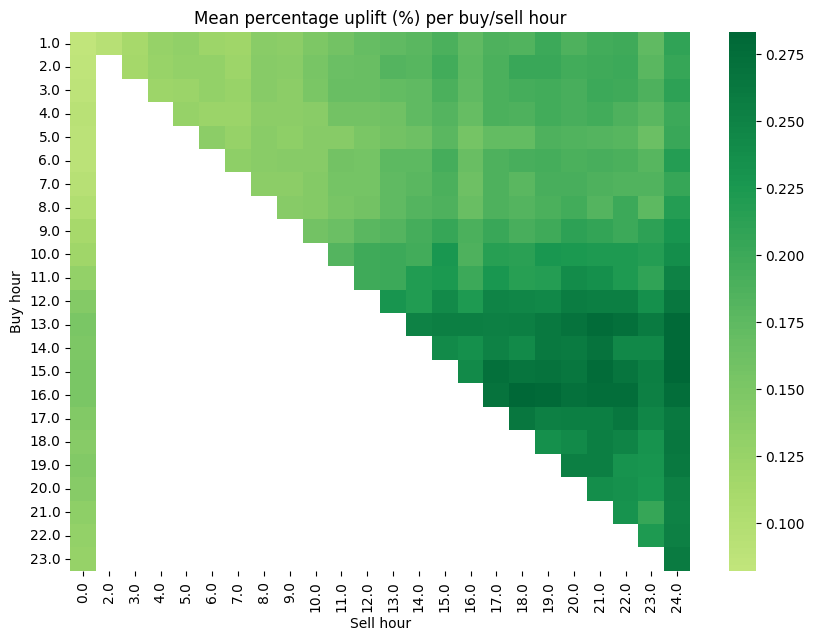

In [234]:
heat_mean = df[
    (df["combo_id"] != 0) & (df["uplift_pct"] > 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean percentage uplift (%) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()


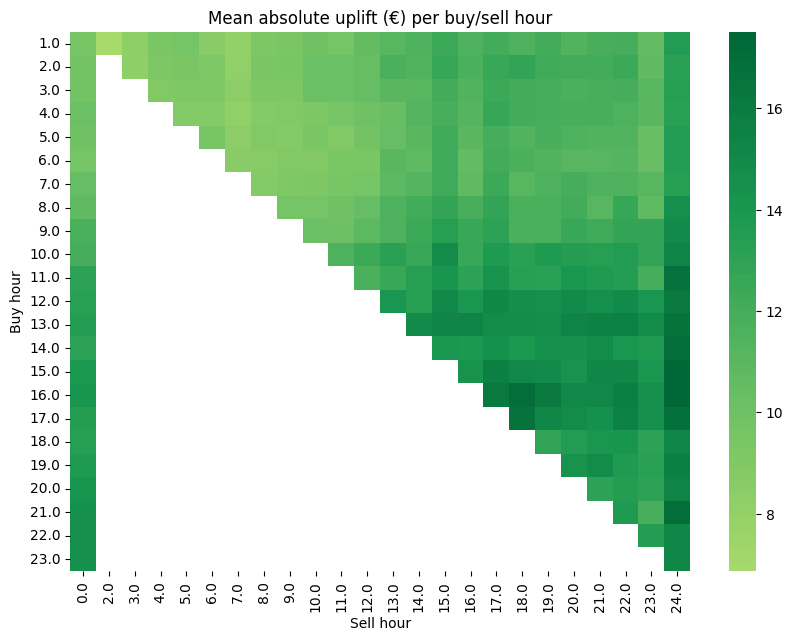

In [235]:
heat_mean = df[
    (df["combo_id"] != 0) & (df["uplift_abs"] > 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_abs",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean absolute uplift (€) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()


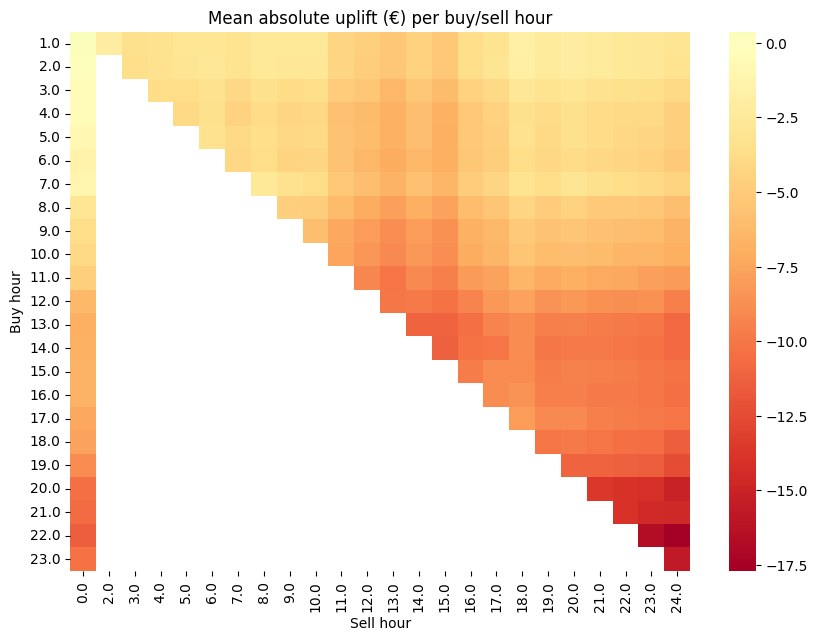

In [236]:
heat_mean = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_abs",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean absolute uplift (€) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()

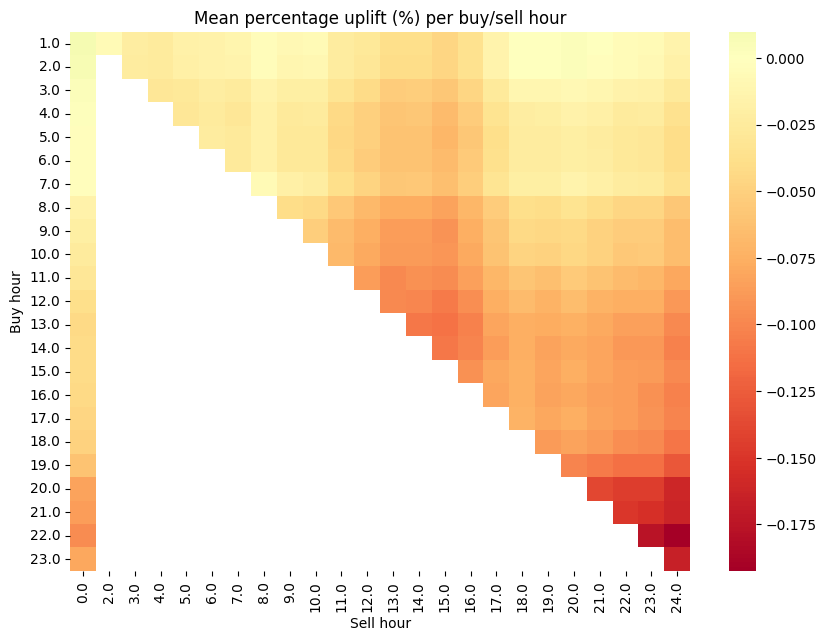

In [237]:
heat_mean = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean percentage uplift (%) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()

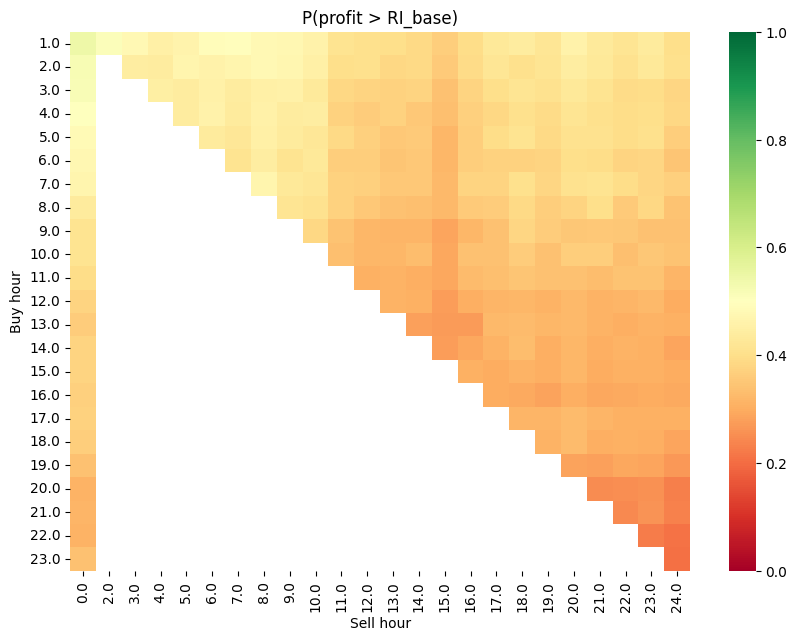

In [238]:
heat_freq = df[df["combo_id"] != 0].assign(
    better=lambda x: x["uplift_abs"] > 0
).pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="better",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_freq, vmin=0, vmax=1,cmap="RdYlGn") #cmap="viridis")
plt.title("P(profit > RI_base)")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()


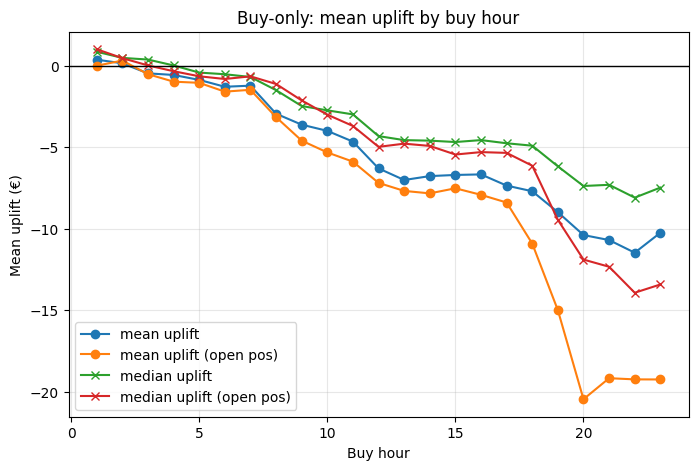

In [239]:
def compute_buy_only_stats(df):
    buy_only = df[(df["kind"] == "buy_only") & (df["combo_id"] != 0)]

    stats = (
        buy_only
        .groupby("buy_hour")["uplift_abs"]
        .agg(
            mean="mean",
            median="median",
            success_rate=lambda x: (x > 0).mean(),
            count="count",
        )
        .reset_index()
    )
    return stats

stats_df = compute_buy_only_stats(df)
stats_df_open_pos = compute_buy_only_stats(df_open_pos)


plt.figure(figsize=(8, 5))
plt.plot(
    stats_df["buy_hour"],
    stats_df["mean"],
    label="mean uplift",
    marker="o"
)

plt.plot(
    stats_df_open_pos["buy_hour"],
    stats_df_open_pos["mean"],
    label="mean uplift (open pos)",
    marker="o"
)

plt.plot(
    stats_df["buy_hour"],
    stats_df["median"],
    label="median uplift",
    marker="x"
)

plt.plot(
    stats_df_open_pos["buy_hour"],
    stats_df_open_pos["median"],
    label="median uplift (open pos)",
    marker="x"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Buy-only: mean uplift by buy hour")
plt.xlabel("Buy hour")
plt.ylabel("Mean uplift (€)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



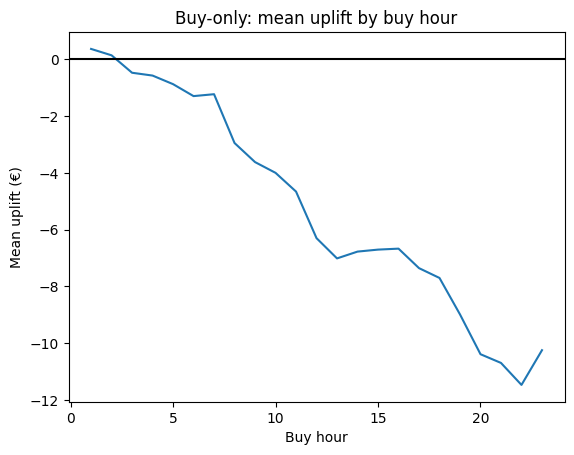

In [240]:
buy_only = df[(df["kind"] == "buy_only") & (df["combo_id"] != 0)]

buy_only_stats = buy_only.groupby("buy_hour")["uplift_abs"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count",
).reset_index()

buy_only_stats

import matplotlib.pyplot as plt

plt.plot(buy_only_stats["buy_hour"], buy_only_stats["mean"])
plt.axhline(0, color="black")
plt.title("Buy-only: mean uplift by buy hour")
plt.xlabel("Buy hour")
plt.ylabel("Mean uplift (€)")
plt.show()

In [241]:
df["holding_time"] = df["sell_hour"] - df["buy_hour"]

df.groupby("holding_time")["uplift_abs"].agg(
    mean="mean",
    median="median",
    count="count"
).reset_index()


,holding_time,mean,median,count
0,-23.0,-10.249138,-7.479071,1496
1,-22.0,-11.473273,-8.094997,1496
2,-21.0,-10.698119,-7.308100,1496
3,-20.0,-10.390784,-7.381188,1496
4,-19.0,-8.988424,-6.175440,1496
5,-18.0,-7.702790,-4.907582,1496
6,-17.0,-7.356431,-4.759506,1496
7,-16.0,-6.669287,-4.564897,1496
8,-15.0,-6.703311,-4.683159,1496
9,-14.0,-6.773456,-4.598362,1496


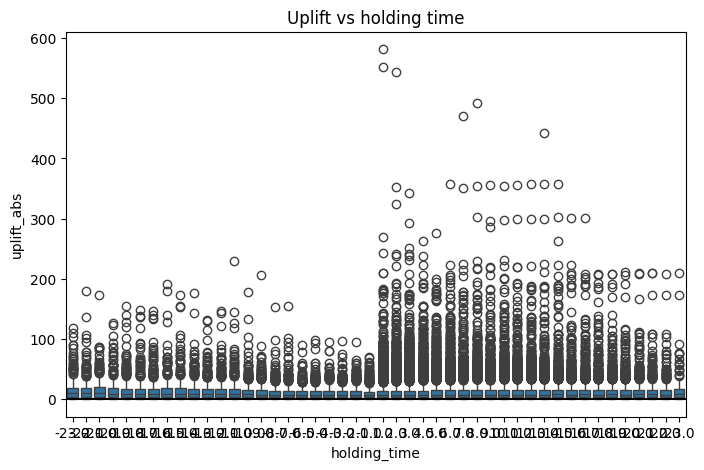

In [242]:
plt.figure(figsize=(8,5))
sns.boxplot(x="holding_time", y="uplift_abs", data=df[df["uplift_abs"]>0])
plt.axhline(0, color="black")
plt.title("Uplift vs holding time")
plt.show()

In [243]:
df.groupby("buy_hour")["uplift_abs"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count"
)

,mean,median,success_rate,count
buy_hour,,,,
1.0,-2.923869,-1.329655,0.446506,20264
2.0,-3.030678,-1.662882,0.433104,19448
3.0,-3.764800,-2.268002,0.417347,18632
4.0,-4.278427,-2.507542,0.409070,17816
5.0,-4.269003,-2.733195,0.402588,17000
6.0,-4.594608,-3.137134,0.388285,16184
7.0,-4.047597,-2.878108,0.395302,15368
8.0,-5.445845,-3.952355,0.375069,14552
9.0,-6.370158,-5.081976,0.346899,13736


In [244]:

df.groupby("sell_hour")["uplift_abs"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count"
)


,mean,median,success_rate,count
sell_hour,,,,
0.0,-5.193190,-2.735387,0.407638,34408
2.0,-1.984152,0.144777,0.508578,816
3.0,-3.496864,-0.725182,0.460784,1632
4.0,-3.461586,-1.283853,0.446078,2448
5.0,-3.386459,-0.928283,0.452819,3264
6.0,-3.133442,-0.899054,0.459804,4080
7.0,-3.832975,-1.078440,0.445466,4896
8.0,-3.173376,-0.798774,0.460084,5712
9.0,-3.711436,-1.433628,0.441483,6528


In [245]:
q = df["uplift_abs"].quantile(0.95)
top = df[df["uplift_abs"] >= q]

top.groupby(["buy_hour", "sell_hour"]).size().sort_values(ascending=False)


buy_hour  sell_hour
23.0      0.0          103
15.0      0.0          103
16.0      0.0          101
21.0      0.0          100
12.0      0.0           95
                      ... 
1.0       2.0           23
6.0       11.0          22
5.0       12.0          22
4.0       7.0           21
5.0       7.0           19
Length: 299, dtype: int64

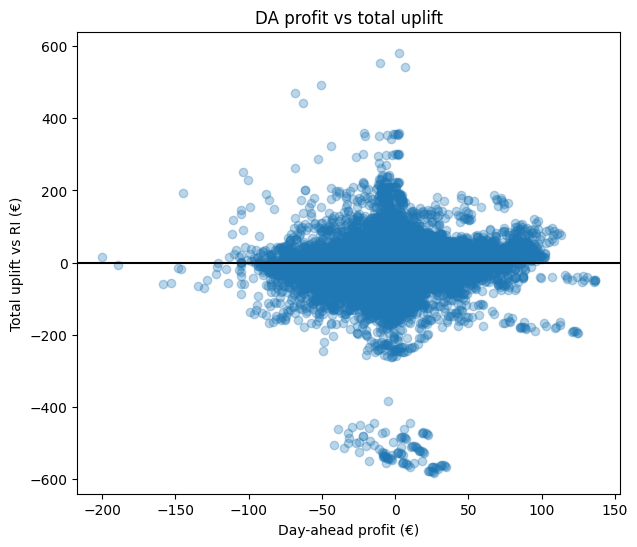

In [246]:
plt.figure(figsize=(7,6))
plt.scatter(df["da_profit"], df["uplift_abs"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Day-ahead profit (€)")
plt.ylabel("Total uplift vs RI (€)")
plt.title("DA profit vs total uplift")
plt.show()


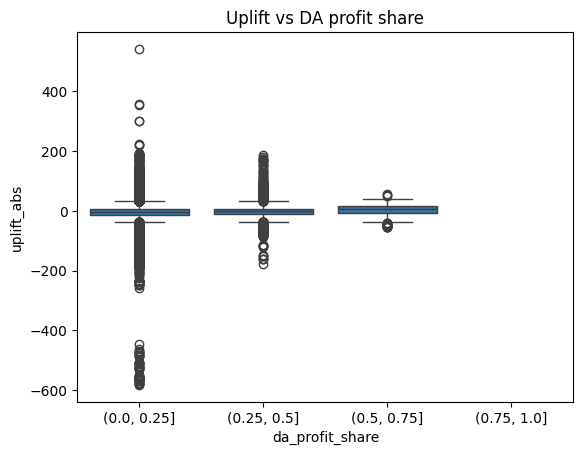

In [247]:
sns.boxplot(x=pd.cut(df["da_profit_share"], bins=[0,0.25,0.5,0.75,1]),
            y=df["uplift_abs"])
plt.title("Uplift vs DA profit share")
plt.show()


In [248]:
g = (df[df.combo_id != 0]
     .groupby(["buy_hour","sell_hour"])
     .apply(lambda x: pd.Series({
         "success_rate": (x.uplift_abs > 0).mean(),
         "mean": x.uplift_abs.mean(),
         "p95": x.uplift_abs.quantile(0.95),
         "p99": x.uplift_abs.quantile(0.99),
         "n": len(x),
     }))
     .reset_index())

pairs = g.to_dict("records")
pareto = []
for i,a in enumerate(pairs):
    dominated = False
    for j,b in enumerate(pairs):
        if i==j: 
            continue
        if (b["success_rate"] >= a["success_rate"] and b["p95"] >= a["p95"]
            and (b["success_rate"] > a["success_rate"] or b["p95"] > a["p95"])):
            dominated = True
            break
    if not dominated:
        pareto.append(a)
pareto_df = pd.DataFrame(pareto).sort_values(["success_rate","p95"], ascending=False)

pareto_df



/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_90955/815439649.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,buy_hour,sell_hour,success_rate,mean,p95,p99,n
0,1.0,0.0,0.543449,0.371334,22.431374,40.078687,1496.0
3,2.0,0.0,0.522727,0.145969,22.556101,40.823975,1496.0
5,3.0,0.0,0.518717,-0.468779,23.946002,37.412202,1496.0
4,2.0,20.0,0.443627,-2.038970,24.514476,48.212487,816.0
1,1.0,21.0,0.431373,-2.394204,26.425034,46.710521,816.0
2,1.0,24.0,0.401961,-3.010582,26.902785,57.857721,816.0
8,23.0,0.0,0.336898,-10.249138,27.160435,55.272237,1496.0
6,13.0,18.0,0.325980,-8.950353,28.442983,61.675460,816.0
7,13.0,24.0,0.307598,-10.783773,28.478489,67.011279,816.0


In [249]:
syn = df[df.combo_id != 0].copy()

topk = (syn.sort_values(["day","uplift_abs"], ascending=[True, False])
          .groupby("day")
          .head(5))

counts = (topk.groupby(["buy_hour","sell_hour"])
              .size()
              .sort_values(ascending=False)
              .head(20))
counts


buy_hour  sell_hour
1.0       0.0          244
2.0       0.0          221
3.0       0.0          214
4.0       0.0          200
23.0      0.0          191
5.0       0.0          183
6.0       0.0          174
8.0       0.0          172
7.0       0.0          169
22.0      0.0          166
9.0       0.0          166
21.0      0.0          161
18.0      0.0          156
17.0      0.0          156
15.0      0.0          154
16.0      0.0          146
10.0      0.0          145
20.0      0.0          145
12.0      0.0          140
19.0      0.0          135
dtype: int64

In [250]:
def cvar(x, alpha=0.1):
    q = x.quantile(alpha)
    return x[x <= q].mean()

risk = (syn.groupby(["buy_hour","sell_hour"])["uplift_abs"]
          .apply(lambda x: pd.Series({
              "mean": x.mean(),
              "cvar10": cvar(x, 0.1),
              "p95": x.quantile(0.95),
              "success": (x>0).mean(),
          }))
          .reset_index())
risk

,buy_hour,sell_hour,level_2,uplift_abs
0,1.0,0.0,mean,0.371334
1,1.0,0.0,cvar10,-30.286458
2,1.0,0.0,p95,22.431374
3,1.0,0.0,success,0.543449
4,1.0,2.0,mean,-1.984152
...,...,...,...,...
1191,23.0,0.0,success,0.336898
1192,23.0,24.0,mean,-15.584255
1193,23.0,24.0,cvar10,-65.725650
1194,23.0,24.0,p95,20.201175


In [251]:
df.sort_values("uplift_pct", ascending=False).head(50)

,day,combo_id,kind,buy_hour,sell_hour,profit,da_exec_time,da_profit,da_buy_price,da_sell_price,da_profit_share,RI_base,uplift_abs,uplift_pct,holding_time
66567,2019-08-09 00:00:00+00:00,267,buy_sell,16.0,20.0,211.047927,2019-08-09 13:00:00,67.5980,-44.98,26.30,0.32,24.812314,186.235613,7.505774,4.0
66565,2019-08-09 00:00:00+00:00,265,buy_sell,16.0,18.0,211.008447,2019-08-09 13:00:00,44.9628,-44.98,-0.02,0.21,24.812314,186.196133,7.504183,2.0
66564,2019-08-09 00:00:00+00:00,264,buy_sell,16.0,17.0,205.348852,2019-08-09 13:00:00,28.4508,-44.98,-19.22,0.14,24.812314,180.536538,7.276086,1.0
66559,2019-08-09 00:00:00+00:00,259,buy_sell,15.0,20.0,204.373341,2019-08-09 13:00:00,72.2380,-49.62,26.30,0.35,24.812314,179.561027,7.236771,5.0
66316,2019-08-09 00:00:00+00:00,16,buy_only,16.0,0.0,204.244669,2019-08-09 13:00:00,44.9800,-44.98,NaN,0.22,24.812314,179.432355,7.231585,-16.0
66568,2019-08-09 00:00:00+00:00,268,buy_sell,16.0,21.0,200.124950,2019-08-09 13:00:00,68.9740,-44.98,27.90,0.34,24.812314,175.312637,7.065550,5.0
66557,2019-08-09 00:00:00+00:00,257,buy_sell,15.0,18.0,197.848069,2019-08-09 13:00:00,49.6028,-49.62,-0.02,0.25,24.812314,173.035756,6.973786,3.0
66571,2019-08-09 00:00:00+00:00,271,buy_sell,16.0,24.0,197.777887,2019-08-09 13:00:00,69.7824,-44.98,28.84,0.35,24.812314,172.965573,6.970957,8.0
66570,2019-08-09 00:00:00+00:00,270,buy_sell,16.0,23.0,197.761997,2019-08-09 13:00:00,72.3538,-44.98,31.83,0.37,24.812314,172.949683,6.970317,7.0
66315,2019-08-09 00:00:00+00:00,15,buy_only,15.0,0.0,197.570083,2019-08-09 13:00:00,49.6200,-49.62,NaN,0.25,24.812314,172.757769,6.962582,-15.0


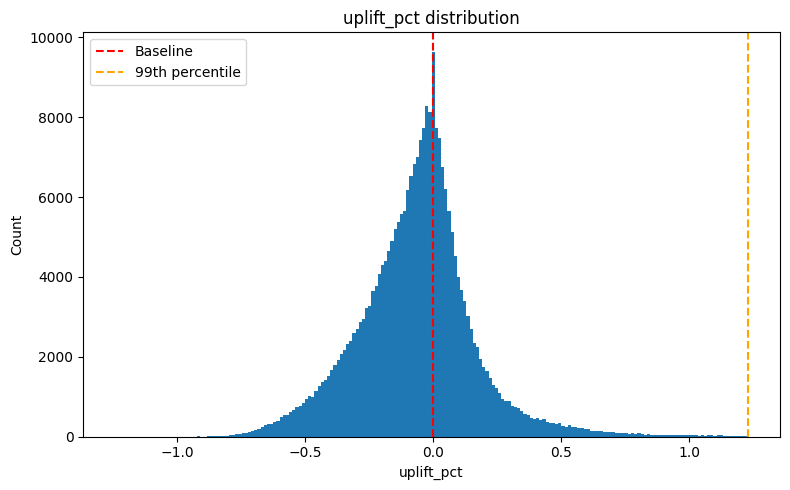

In [252]:
import matplotlib.pyplot as plt
import numpy as np

uplift = df["uplift_pct"].dropna()

q99 = uplift.quantile(0.995)

plt.figure(figsize=(8, 5))
plt.hist(uplift[uplift <= q99], bins=200)
plt.axvline(0, color="red", linestyle="--", label="Baseline")
plt.axvline(q99, color="orange", linestyle="--", label="99th percentile")
plt.xlabel("uplift_pct")
plt.ylabel("Count")
plt.title("uplift_pct distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [253]:
df

,day,combo_id,kind,buy_hour,sell_hour,profit,da_exec_time,da_profit,da_buy_price,da_sell_price,da_profit_share,RI_base,uplift_abs,uplift_pct,holding_time
0,2018-12-31 00:00:00+00:00,0,no_da,NaN,NaN,68.233139,2018-12-31 13:00:00,0.00,NaN,NaN,0.00,68.233139,0.000000,0.000000,NaN
1,2018-12-31 00:00:00+00:00,1,buy_only,1.0,0.0,61.759133,2018-12-31 13:00:00,-28.32,28.32,NaN,-0.46,68.233139,-6.474006,-0.094881,-1.0
2,2018-12-31 00:00:00+00:00,2,buy_only,2.0,0.0,60.593526,2018-12-31 13:00:00,-10.07,10.07,NaN,-0.17,68.233139,-7.639613,-0.111963,-2.0
3,2018-12-31 00:00:00+00:00,3,buy_only,3.0,0.0,80.214991,2018-12-31 13:00:00,4.08,-4.08,NaN,0.05,68.233139,11.981852,0.175602,-3.0
4,2018-12-31 00:00:00+00:00,4,buy_only,4.0,0.0,69.708946,2018-12-31 13:00:00,9.91,-9.91,NaN,0.14,68.233139,1.475806,0.021629,-4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261115,2023-02-03 00:00:00+00:00,19,buy_only,19.0,0.0,97.329188,NaN,NaN,NaN,NaN,NaN,128.534441,-31.205253,-0.242777,-19.0
261116,2023-02-03 00:00:00+00:00,20,buy_only,20.0,0.0,103.206982,NaN,NaN,NaN,NaN,NaN,128.534441,-25.327459,-0.197048,-20.0
261117,2023-02-03 00:00:00+00:00,21,buy_only,21.0,0.0,113.102283,NaN,NaN,NaN,NaN,NaN,128.534441,-15.432158,-0.120062,-21.0
261118,2023-02-03 00:00:00+00:00,22,buy_only,22.0,0.0,98.504620,NaN,NaN,NaN,NaN,NaN,128.534441,-30.029821,-0.233632,-22.0


In [254]:
df["date"] = df["day"].dt.date

<Figure size 2000x1000 with 0 Axes>

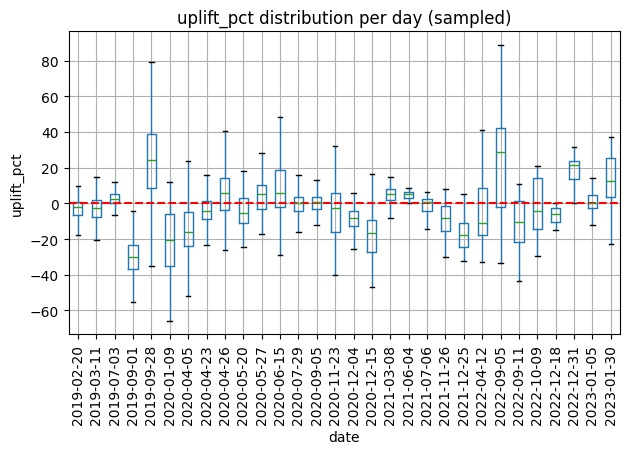

In [255]:
# Sample Tage (sonst zu groß)
sample_days = df["date"].drop_duplicates().sample(n=30, random_state=42)
df_sample = df[df["date"].isin(sample_days)]

plt.figure(figsize=(20, 10))
df_sample.boxplot(
    column="uplift_abs",
    by="date",
    showfliers=False,
    rot=90
)
plt.axhline(0, color="red", linestyle="--")
plt.title("uplift_pct distribution per day (sampled)")
plt.suptitle("")
plt.ylabel("uplift_pct")
plt.tight_layout()
plt.show()


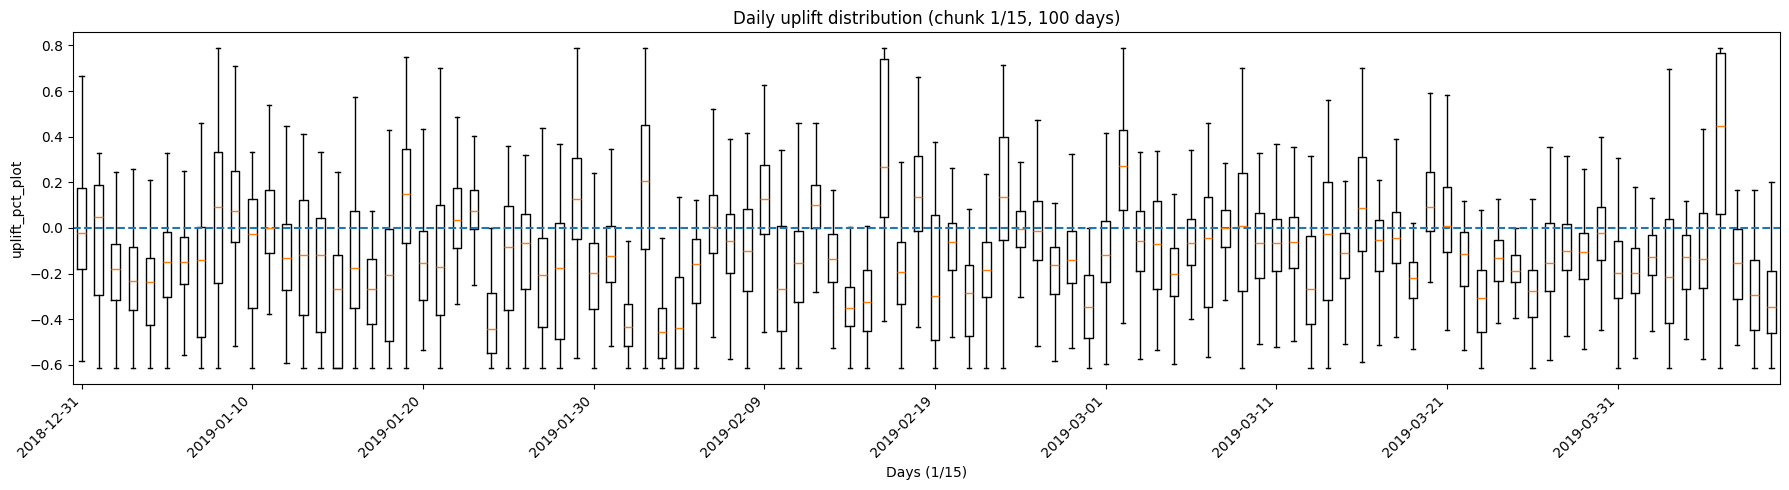

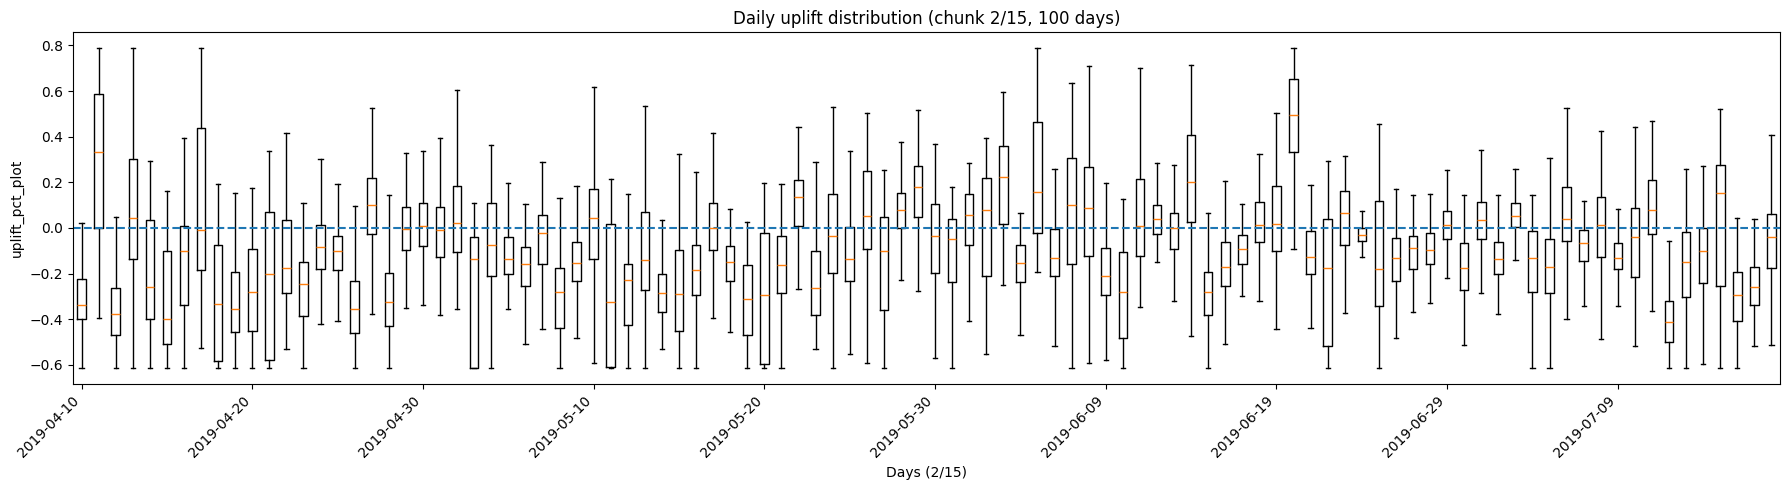

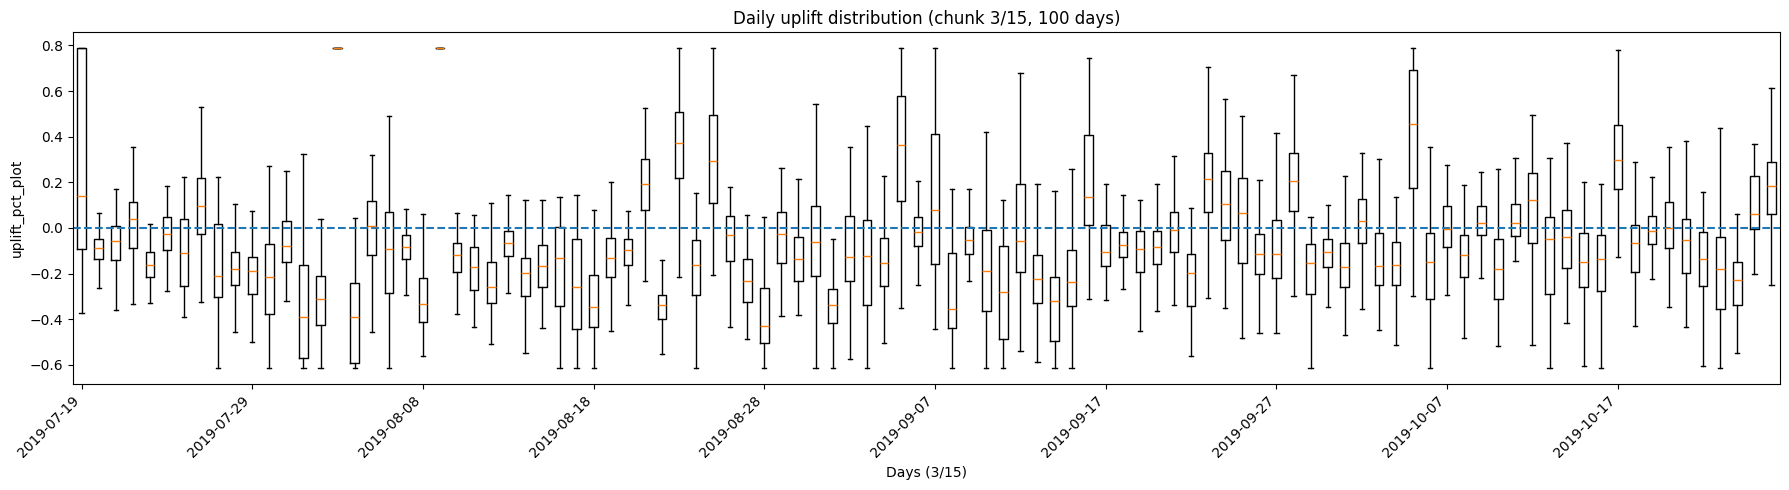

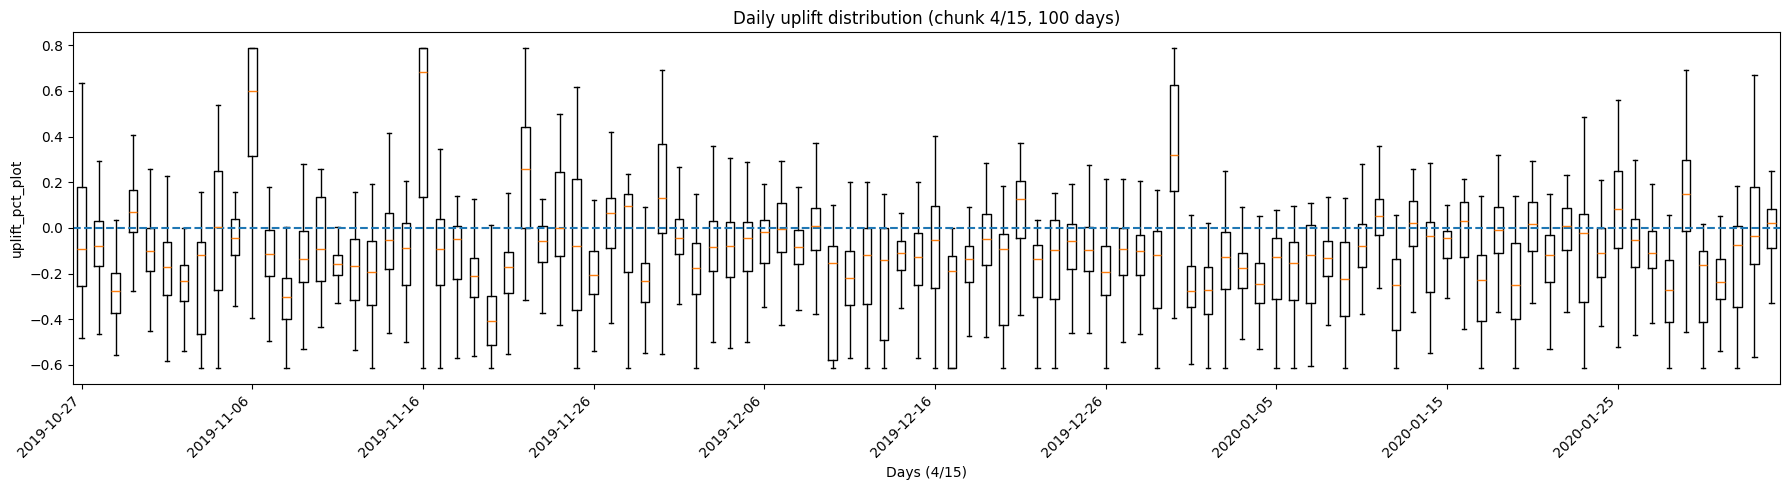

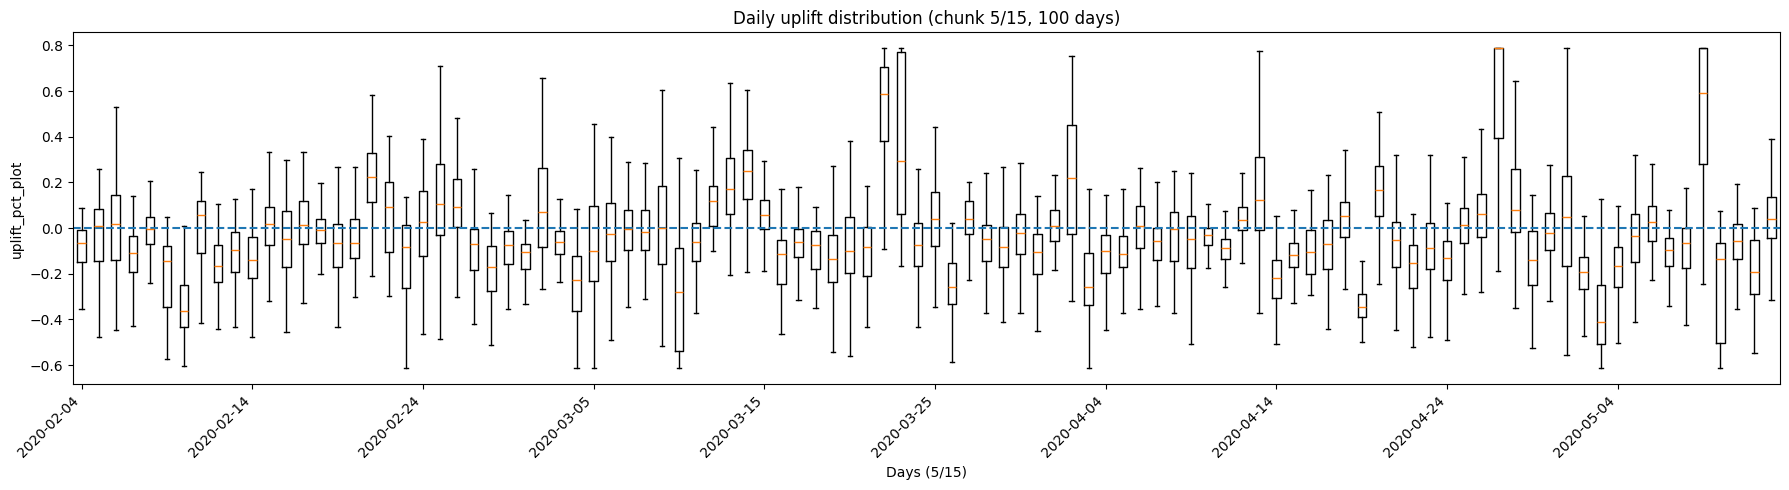

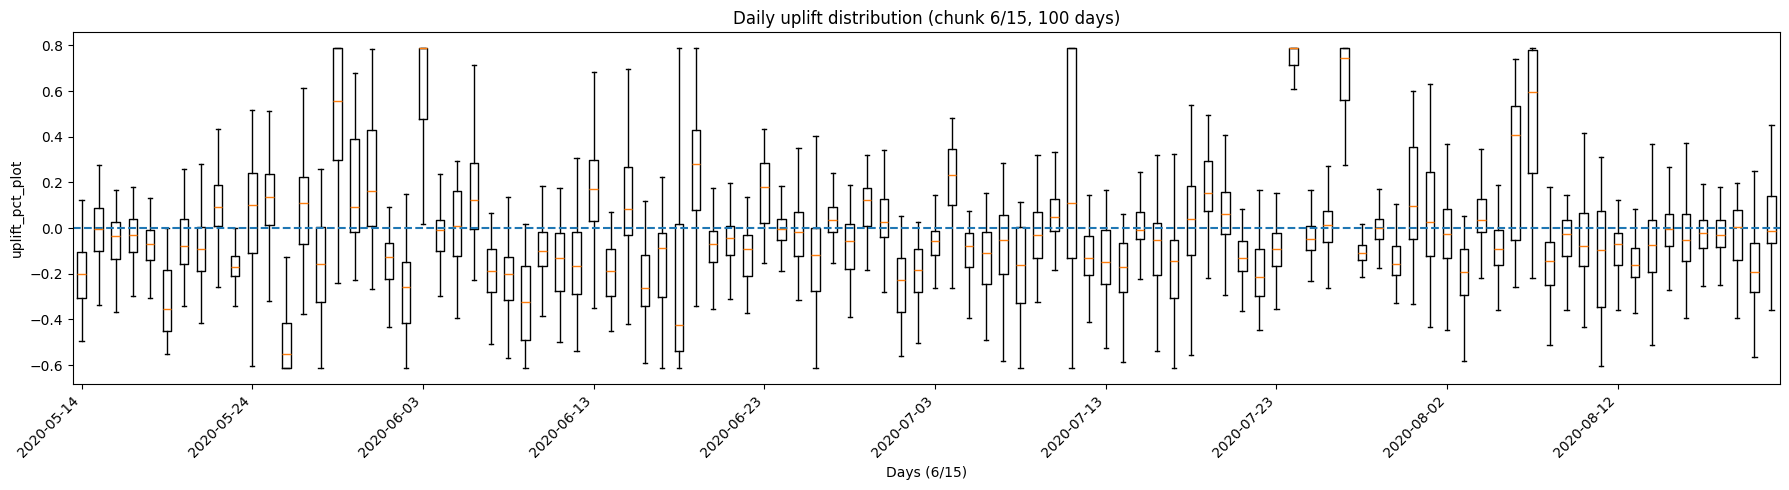

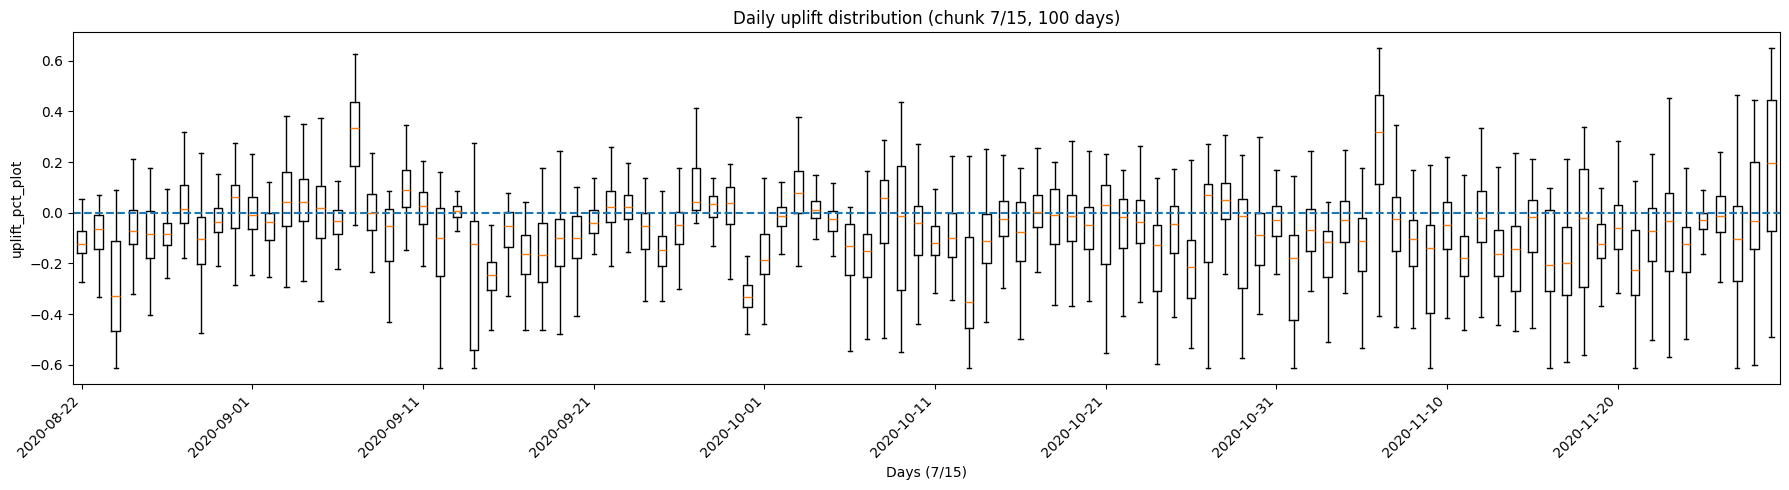

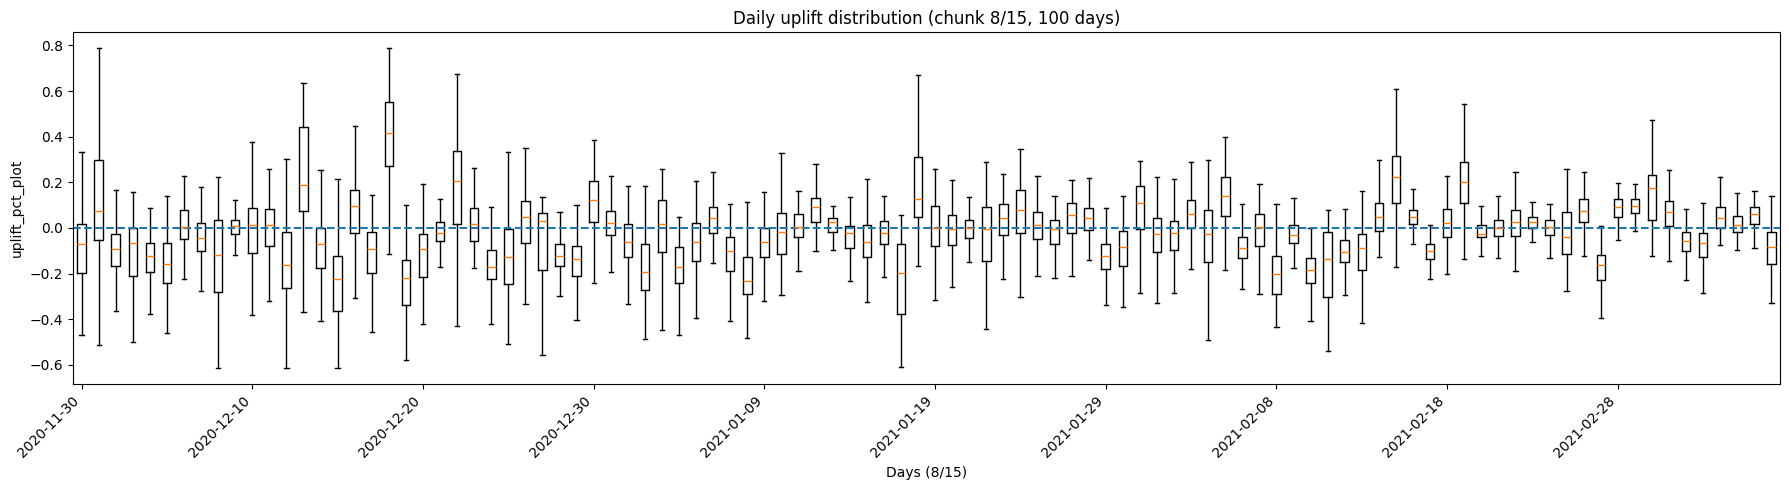

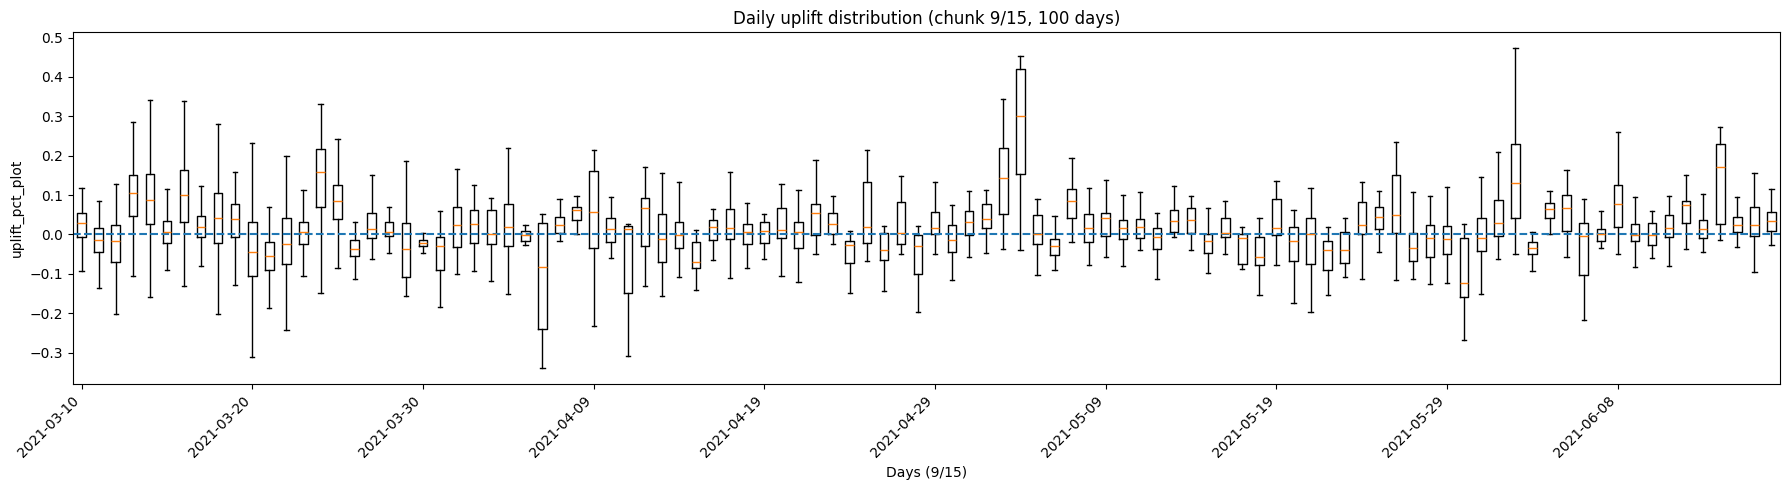

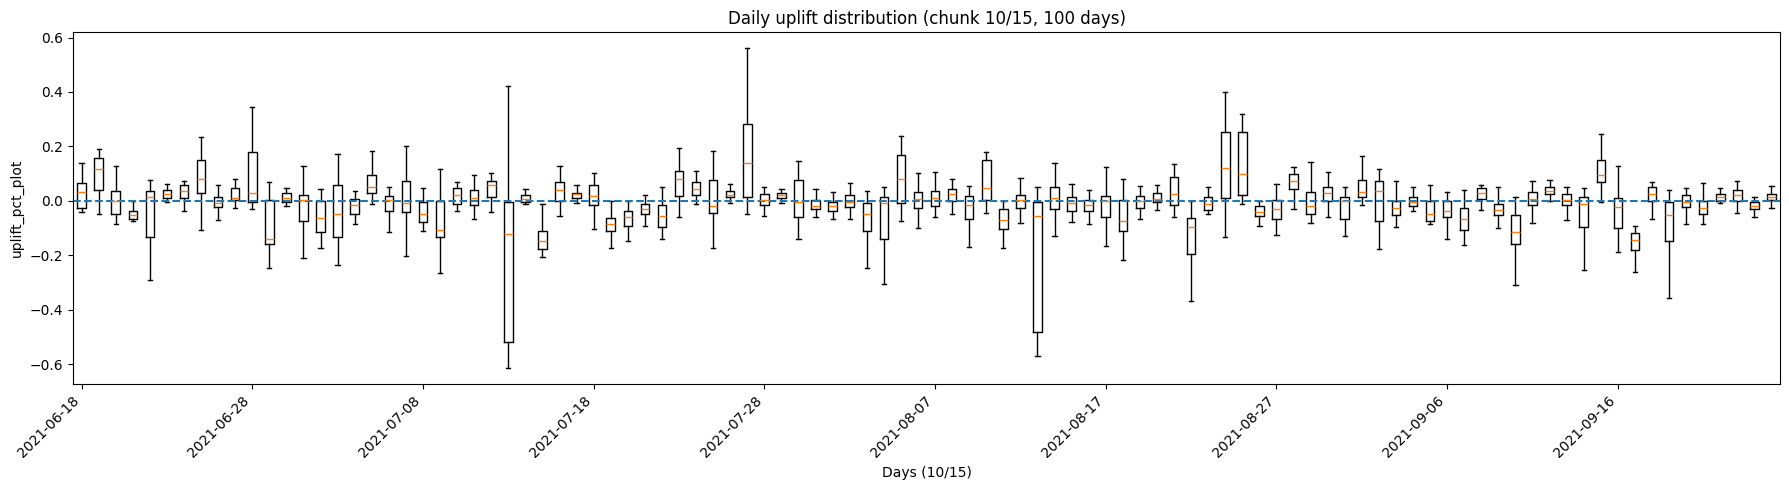

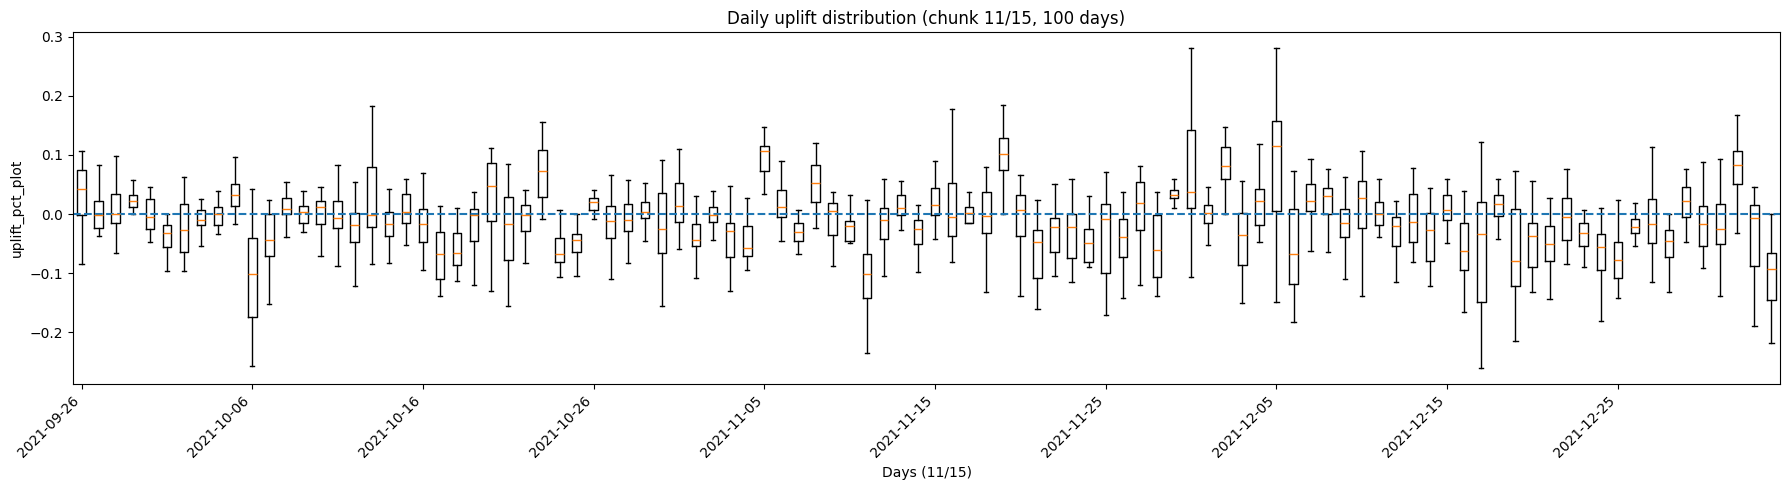

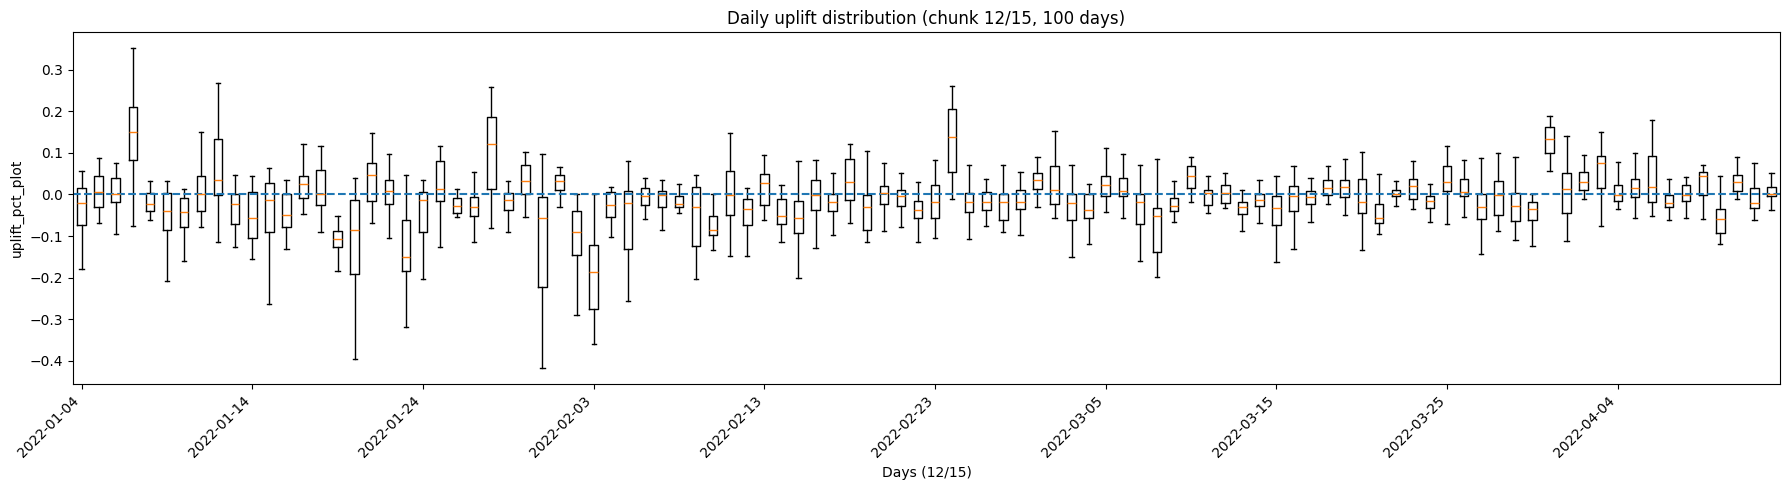

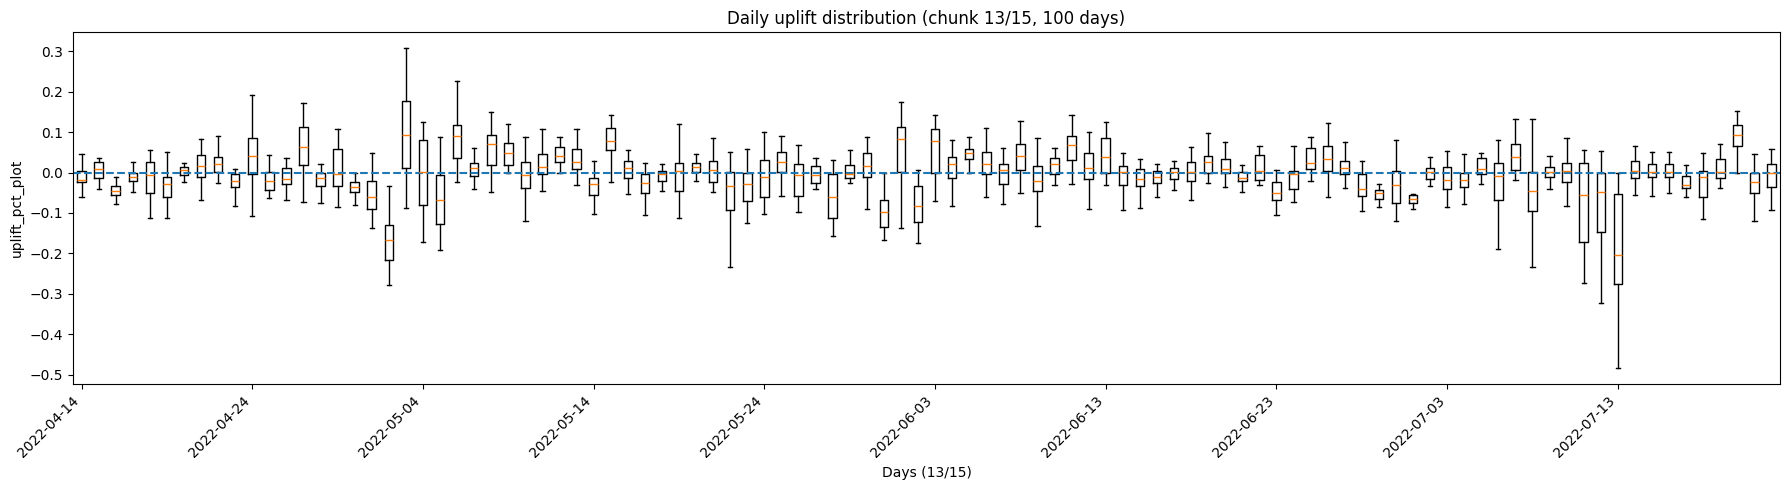

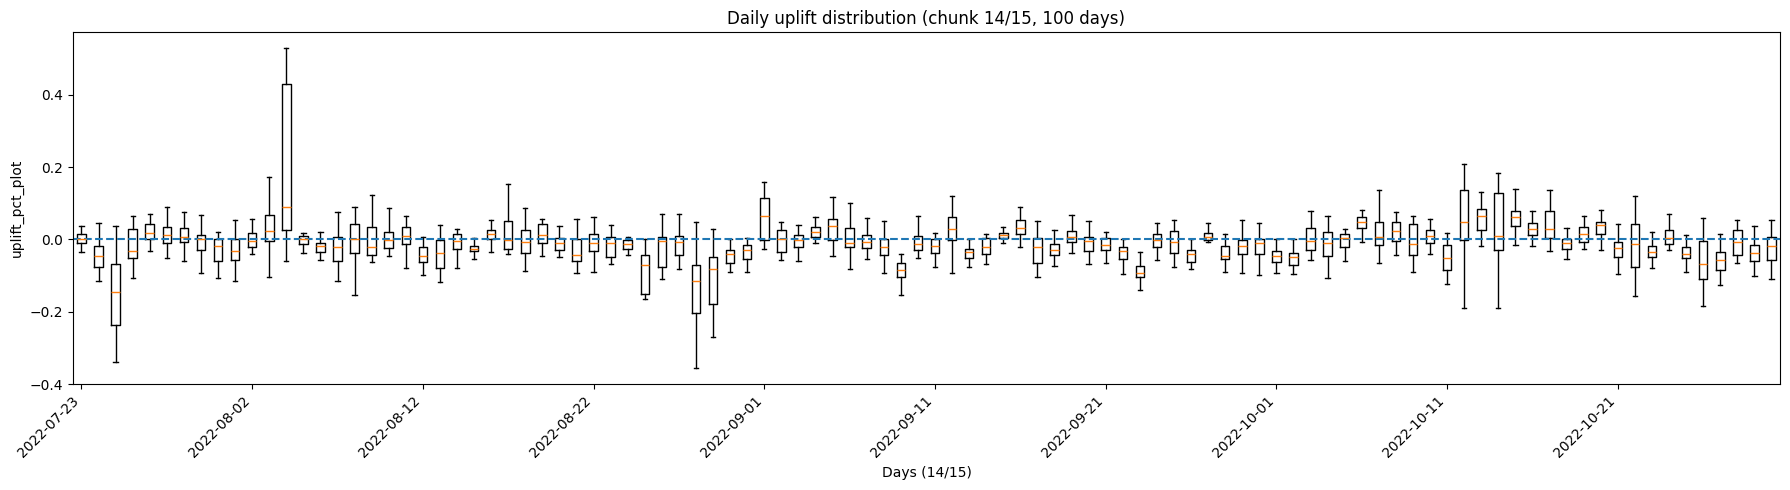

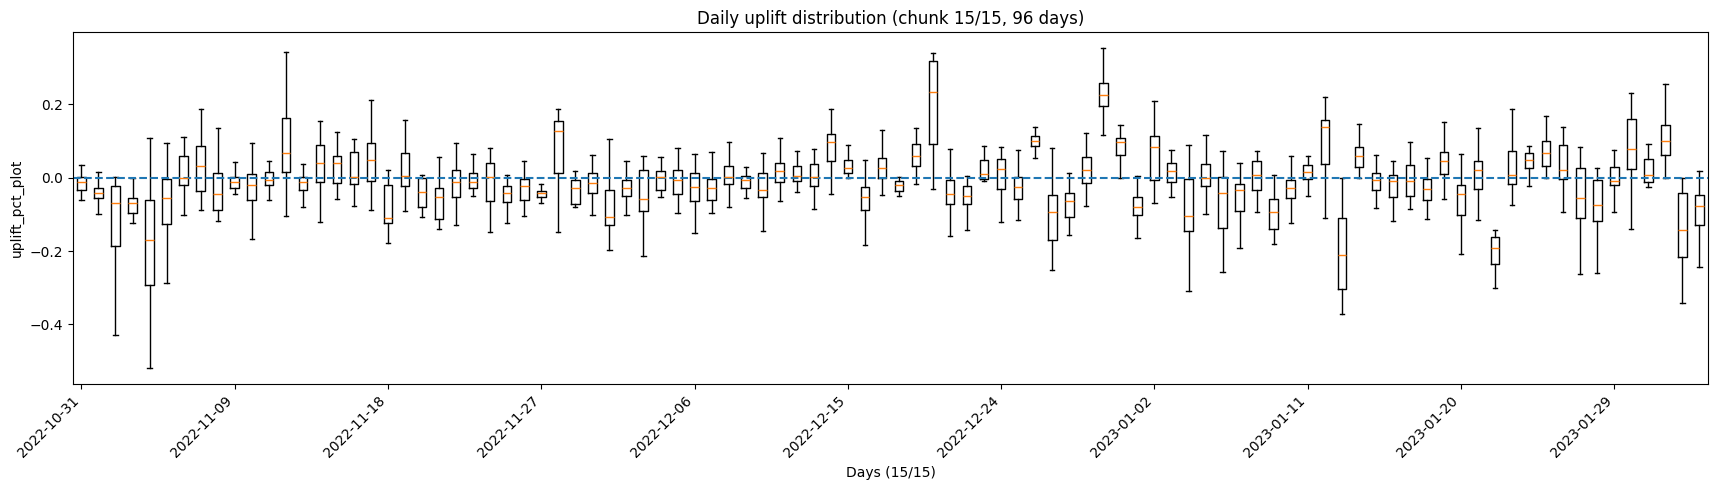

In [256]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_boxplots_by_day_chunks(
    df: pd.DataFrame,
    date_col: str = "date",
    value_col: str = "uplift_pct",
    chunk_size: int = 80,
    sort_days: str = "date",   # "date" oder "median" oder "mean"
    showfliers: bool = False,
):
    d = df[[date_col, value_col]].dropna().copy()

    # Liste aller Tage
    days = d[date_col].drop_duplicates()

    # Sortierung (optional hilfreich)
    if sort_days == "median":
        day_order = (d.groupby(date_col)[value_col].median()
                       .sort_values(ascending=True).index.tolist())
    elif sort_days == "mean":
        day_order = (d.groupby(date_col)[value_col].mean()
                       .sort_values(ascending=True).index.tolist())
    else:
        # nach Datum (sicher, wenn date echtes Date/Datetime ist)
        day_order = sorted(days.tolist())

    # Daten pro Tag einmal vorbereiten (spart Zeit)
    grouped = {day: d.loc[d[date_col] == day, value_col].values for day in day_order}

    n = len(day_order)
    n_chunks = int(np.ceil(n / chunk_size))

    for i in range(n_chunks):
        chunk_days = day_order[i*chunk_size:(i+1)*chunk_size]
        data = [grouped[day] for day in chunk_days]

        plt.figure(figsize=(max(12, len(chunk_days)*0.18), 5))
        plt.boxplot(data, showfliers=showfliers)

        # Baseline-Linie
        plt.axhline(0, linestyle="--")

        # X-Achse: nicht jeden Tag labeln (sonst zu voll)
        tick_step = max(1, len(chunk_days)//10)
        ticks = np.arange(1, len(chunk_days)+1, tick_step)
        labels = [str(chunk_days[t-1]) for t in ticks]

        plt.xticks(ticks, labels, rotation=45, ha="right")
        plt.xlabel(f"Days ({i+1}/{n_chunks})")
        plt.ylabel(value_col)
        plt.title(f"Daily uplift distribution (chunk {i+1}/{n_chunks}, {len(chunk_days)} days)")
        plt.tight_layout()
        plt.show()

q01, q99 = df["uplift_pct"].quantile([0.01, 0.99])
df["uplift_pct_plot"] = df["uplift_pct"].clip(q01, q99)
# Aufruf
plot_boxplots_by_day_chunks(
    df,
    date_col="date",
    value_col="uplift_pct_plot",
    chunk_size=100,     # probier 50, 80, 100
    sort_days="date",  # oder "median"
    showfliers=False
)


#### Load drl observation space features

In [257]:
drl_obs_data = pd.read_csv("../data/simplified_data_jan_with_exaa_and_id_full/df_spot_train_2019-01-01_2024-12-31_with_features_utc.csv")
drl_obs_data["time"] = pd.to_datetime(drl_obs_data["time"], utc=True)
drl_obs_data.set_index("time", inplace=True)
drl_obs_data = drl_obs_data.resample('D').mean()
drl_obs_data.reset_index(inplace=True)
drl_obs_data["date"] = drl_obs_data["time"].dt.date
drl_obs_data

df["day"] = pd.to_datetime(df["day"].astype(str).str.slice(0, 10), errors="coerce")
df["day_utc"] = df["day"].dt.tz_localize("UTC")
df["date"] = df["day_utc"].dt.date
df

df_merged = df.merge(
    drl_obs_data,
    on="date",
    how="left"
)

In [258]:
columns_to_keep = [ 'date','buy_hour', 'sell_hour',
      'uplift_abs', 'uplift_pct',
       'load_forecast_d_minus_1_1000_total_de_lu_mw',
       'pv_forecast_d_minus_1_1000_de_lu_mw',
       'wind_offshore_forecast_d_minus_1_1000_de_lu_mw',
       'wind_onshore_forecast_d_minus_1_1000_de_lu_mw', 'date_month',
       'day_of_week', 'wind_forecast_daily_mean', 'wind_forecast_daily_std',
       'spread_id_full_da_h_mean', 'spread_id_full_da_h_std',
       'spread_id_full_da_h_min', 'spread_id_full_da_h_max',
       'spread_id_full_da_qh_mean', 'spread_id_full_da_qh_std',
       'spread_id_full_da_qh_min', 'spread_id_full_da_qh_max',
       'exaa_pf_daily_mean', 'exaa_pf_daily_std', 'exaa_pf_daily_min',
       'exaa_pf_daily_max', 'exaa_pf_daily_spread', 'exaa_pf_daily_diff_sum',
       'exaa_pf_daily_diff_max']

df= df_merged[columns_to_keep]


df["buy_hour"] = df["buy_hour"].fillna(0)
df["sell_hour"] = df["sell_hour"].fillna(0)

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_90955/2376290582.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["buy_hour"] = df["buy_hour"].fillna(0)
/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_90955/2376290582.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sell_hour"] = df["sell_hour"].fillna(0)


In [259]:
"""

import numpy as np
import pandas as pd

def add_action_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Sicherstellen: int
    df["buy_hour"]  = df["buy_hour"].fillna(0).astype(int)
    df["sell_hour"] = df["sell_hour"].fillna(0).astype(int)

    df["has_buy"]  = (df["buy_hour"]  > 0).astype(int)
    df["has_sell"] = (df["sell_hour"] > 0).astype(int)
    df["is_roundtrip"] = ((df["has_buy"] == 1) & (df["has_sell"] == 1)).astype(int)

    # Haltedauer nur wenn roundtrip; sonst 0
    df["hold_duration"] = (df["sell_hour"] - df["buy_hour"]).astype(int)
    df.loc[df["is_roundtrip"] == 0, "hold_duration"] = 0

    # Grobe Zeit-Bins (interpretierbar)
    df["buy_is_early"]   = df["buy_hour"].between(1, 6).astype(int)
    df["buy_is_midday"]  = df["buy_hour"].between(7, 14).astype(int)
    df["buy_is_late"]    = df["buy_hour"].between(15, 23).astype(int)

    df["sell_is_early"]  = df["sell_hour"].between(1, 6).astype(int)
    df["sell_is_midday"] = df["sell_hour"].between(7, 14).astype(int)
    df["sell_is_evening"]= df["sell_hour"].between(17, 23).astype(int)

    # "Flexibility locks" Proxies (DA schränkt IDC ein)
    df["locks_energy_early"] = (df["buy_hour"] <= 6).astype(int) * df["has_buy"]
    df["locks_energy_long"]  = (df["hold_duration"] >= 6).astype(int) * df["is_roundtrip"]
    df["locks_peak_hours"]   = df["sell_hour"].between(17, 21).astype(int) * df["has_sell"]

    # Optional: Kategorie-Label für Aktion (gut für CatBoost; für LGBM eher optional)
    #df["action_id"] = df["buy_hour"].astype(str) + "_" + df["sell_hour"].astype(str)

    return df

df = add_action_features(df)

"""


'\n\nimport numpy as np\nimport pandas as pd\n\ndef add_action_features(df: pd.DataFrame) -> pd.DataFrame:\n    df = df.copy()\n\n    # Sicherstellen: int\n    df["buy_hour"]  = df["buy_hour"].fillna(0).astype(int)\n    df["sell_hour"] = df["sell_hour"].fillna(0).astype(int)\n\n    df["has_buy"]  = (df["buy_hour"]  > 0).astype(int)\n    df["has_sell"] = (df["sell_hour"] > 0).astype(int)\n    df["is_roundtrip"] = ((df["has_buy"] == 1) & (df["has_sell"] == 1)).astype(int)\n\n    # Haltedauer nur wenn roundtrip; sonst 0\n    df["hold_duration"] = (df["sell_hour"] - df["buy_hour"]).astype(int)\n    df.loc[df["is_roundtrip"] == 0, "hold_duration"] = 0\n\n    # Grobe Zeit-Bins (interpretierbar)\n    df["buy_is_early"]   = df["buy_hour"].between(1, 6).astype(int)\n    df["buy_is_midday"]  = df["buy_hour"].between(7, 14).astype(int)\n    df["buy_is_late"]    = df["buy_hour"].between(15, 23).astype(int)\n\n    df["sell_is_early"]  = df["sell_hour"].between(1, 6).astype(int)\n    df["sell_is_mid

In [260]:
df["uplift_pos"] = (df["uplift_abs"] > 0.0).astype(int)
#df["uplift_pos_5pct"] = (df["uplift_pct"] > 0.2).astype(int)


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_90955/467688653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uplift_pos"] = (df["uplift_abs"] > 0.0).astype(int)


In [261]:
from sklearn.model_selection import GroupShuffleSplit

y = df["uplift_pos"].values

exclude = {
    "uplift_abs","uplift_pct","uplift_pos","uplift_pos_5pct",
    "day","time","datetime","date"
}
candidate_cols = [c for c in df.columns if c not in exclude]

groups = df["date"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(df, y, groups=groups))

X_train = df.iloc[train_idx][candidate_cols]
y_train = df.iloc[train_idx]["uplift_pos"]
X_test  = df.iloc[test_idx][candidate_cols]
y_test  = df.iloc[test_idx]["uplift_pos"]



In [262]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

p_test = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, p_test))
print("PR-AUC :", average_precision_score(y_test, p_test))


[LightGBM] [Info] Number of positive: 17401, number of negative: 32003
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5441
[LightGBM] [Info] Number of data points in the train set: 49404, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.352218 -> initscore=-0.609302
[LightGBM] [Info] Start training from score -0.609302
ROC-AUC: 0.578451425353646
PR-AUC : 0.43407607830680645


In [263]:
import numpy as np

def recall_at_topk(y_true, y_score, k_frac=0.2):
    k = int(len(y_true) * k_frac)
    idx = np.argsort(-y_score)[:k]
    return y_true.iloc[idx].sum() / max(1, y_true.sum())

print("Recall@Top20%:", recall_at_topk(y_test, pd.Series(p_test, index=y_test.index), 0.2))


Recall@Top20%: 0.2481658365449866


In [264]:
import pandas as pd

imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(30))


buy_hour                                          9676
sell_hour                                         8048
load_forecast_d_minus_1_1000_total_de_lu_mw       2715
pv_forecast_d_minus_1_1000_de_lu_mw               2648
wind_offshore_forecast_d_minus_1_1000_de_lu_mw    2122
wind_forecast_daily_std                           2063
spread_id_full_da_h_mean                          1930
wind_onshore_forecast_d_minus_1_1000_de_lu_mw     1906
spread_id_full_da_h_min                           1814
spread_id_full_da_h_std                           1617
spread_id_full_da_h_max                           1523
exaa_pf_daily_mean                                1502
exaa_pf_daily_std                                 1447
day_of_week                                       1374
exaa_pf_daily_diff_max                            1358
exaa_pf_daily_min                                 1286
exaa_pf_daily_diff_sum                            1200
date_month                                        1091
exaa_pf_da

/Users/timflaschel/Documents/GitHub/BessBidder1/.venv/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


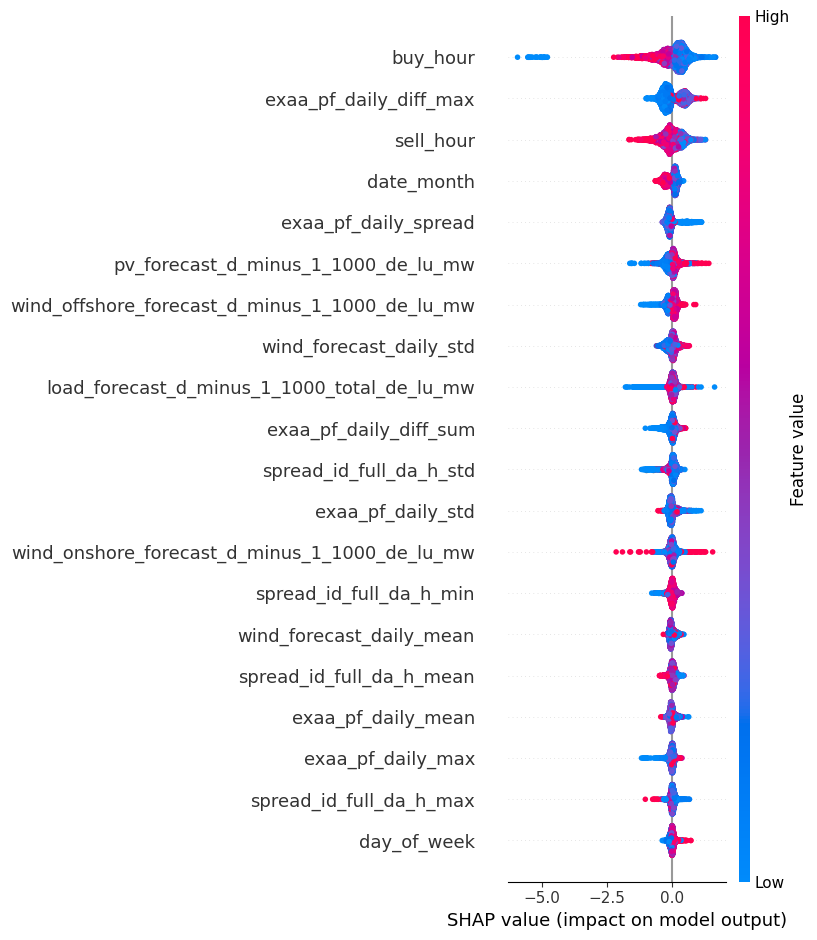

In [265]:
import shap

explainer = shap.TreeExplainer(model)
# Für Geschwindigkeit: sample
sample_idx = X_test.sample(n=min(5000, len(X_test)), random_state=42).index
X_s = X_test.loc[sample_idx]

shap_values = explainer.shap_values(X_s)
# Falls Liste:
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Global summary
shap.summary_plot(shap_values, X_s)


In [266]:
df.columns


Index(['date', 'buy_hour', 'sell_hour', 'uplift_abs', 'uplift_pct',
       'load_forecast_d_minus_1_1000_total_de_lu_mw',
       'pv_forecast_d_minus_1_1000_de_lu_mw',
       'wind_offshore_forecast_d_minus_1_1000_de_lu_mw',
       'wind_onshore_forecast_d_minus_1_1000_de_lu_mw', 'date_month',
       'day_of_week', 'wind_forecast_daily_mean', 'wind_forecast_daily_std',
       'spread_id_full_da_h_mean', 'spread_id_full_da_h_std',
       'spread_id_full_da_h_min', 'spread_id_full_da_h_max',
       'spread_id_full_da_qh_mean', 'spread_id_full_da_qh_std',
       'spread_id_full_da_qh_min', 'spread_id_full_da_qh_max',
       'exaa_pf_daily_mean', 'exaa_pf_daily_std', 'exaa_pf_daily_min',
       'exaa_pf_daily_max', 'exaa_pf_daily_spread', 'exaa_pf_daily_diff_sum',
       'exaa_pf_daily_diff_max', 'uplift_pos'],
      dtype='object')

In [267]:
df_corr = df.drop(columns=["date"])

corr_with_uplift = (
    df_corr
    .corr(method="pearson")["uplift_abs"]
    .sort_values(ascending=False)
)

corr_with_uplift.head(30)

uplift_abs                                        1.000000
uplift_pct                                        0.719805
uplift_pos                                        0.555154
pv_forecast_d_minus_1_1000_de_lu_mw               0.030653
load_forecast_d_minus_1_1000_total_de_lu_mw       0.013184
wind_forecast_daily_std                           0.011711
spread_id_full_da_qh_min                          0.010218
spread_id_full_da_h_min                           0.010218
day_of_week                                       0.008780
wind_offshore_forecast_d_minus_1_1000_de_lu_mw    0.005268
exaa_pf_daily_min                                 0.003372
exaa_pf_daily_mean                               -0.002355
spread_id_full_da_h_max                          -0.003092
spread_id_full_da_qh_max                         -0.003092
spread_id_full_da_h_mean                         -0.005289
spread_id_full_da_qh_mean                        -0.005289
exaa_pf_daily_max                                -0.0079

In [268]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [269]:
# Target
y_col = "uplift_pct"

# Groups (pro Tag)
group_col = "date"
groups = df[group_col]

# Excludes (Targets + Zeitspalten etc.)
exclude = {
    "uplift_abs", "uplift_pct",
    "uplift_pos", "uplift_pos_5pct",
    "day", "time", "datetime", group_col
}
feature_cols = [c for c in df.columns if c not in exclude]

X = df[feature_cols]
y = df[y_col]

# Split by day
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]



In [270]:
use_lgbm = True
try:
    from lightgbm import LGBMRegressor
except Exception:
    use_lgbm = False

if use_lgbm:
    model = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=127,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        #max_depth= 3,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
else:
    from sklearn.ensemble import HistGradientBoostingRegressor
    model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=None,
        max_iter=800,
        random_state=42
    )

model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = mean_squared_error(y_test, pred)
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5453
[LightGBM] [Info] Number of data points in the train set: 209484, number of used features: 25
[LightGBM] [Info] Start training from score -0.048236
RMSE: 0.05441288434541948
MAE : 0.1673150077408959
R2  : -0.10779361343833815


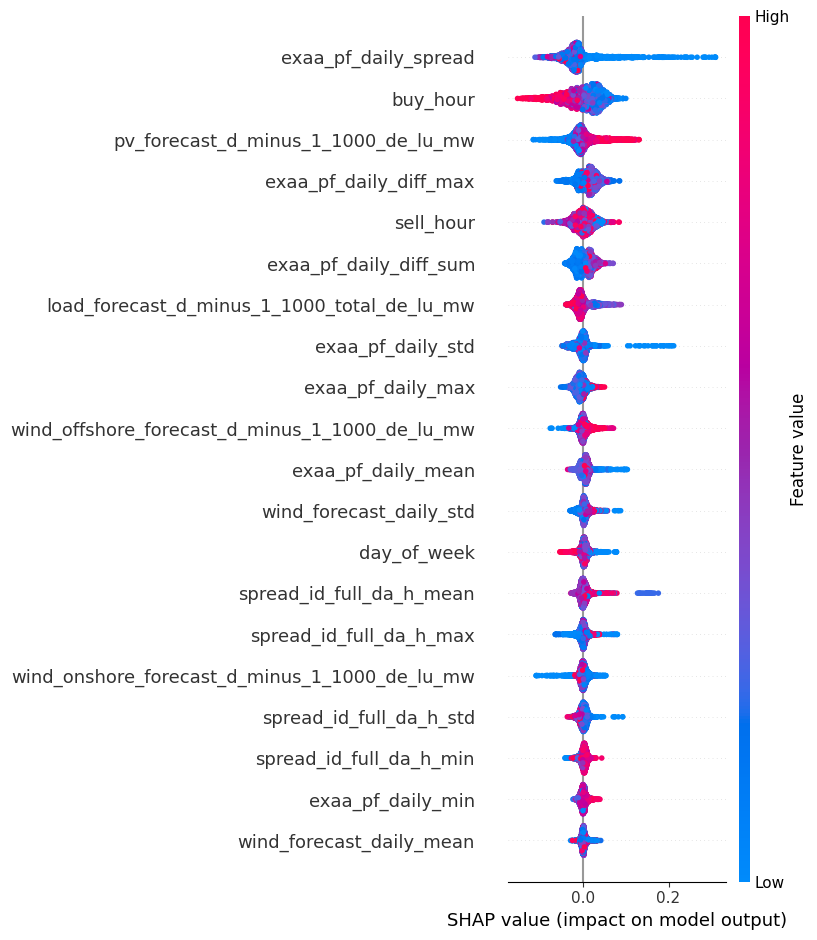

In [271]:
import shap

# SHAP auf Sample (sonst zu langsam)
sample_n = 5000
X_shap = X_test.sample(n=min(sample_n, len(X_test)), random_state=42)

if use_lgbm:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
else:
    # für HistGB geht TreeExplainer oft auch, ansonsten KernelExplainer (sehr langsam)
    explainer = shap.Explainer(model, X_train.sample(n=2000, random_state=42))
    shap_values = explainer(X_shap)

# Summary plot (global importance + direction)
shap.summary_plot(shap_values, X_shap)


In [272]:
import pandas as pd
test = pd.read_csv("../output/coordinated_multi_market/logging/23/reward_components.csv")
#test["episode_start_timestamp"] = pd.to_datetime(test["episode_start_timestamp"].astype(str).str.slice(0, 10), errors="coerce")
#test["episode_start_timestamp"] = test["episode_start_timestamp"].dt.normalize()
#test.set_index("episode_start_timestamp", inplace=True)

In [273]:
test

,episode_start_timestamp,episode_len,lambda,da_profit_eur,idc_profit_eur,da_reward_sum,idc_reward_sum,combined_reward_sum,da_reward_mean,idc_reward_step,combined_reward_mean,baseline_profit_eur
0,2019-06-15 00:00:00+02:00,6,0.5,-20.753400,0.000000,-0.400380,0.0,-0.400380,-0.066730,0.0,-0.066730,NaN
1,2019-12-06 00:00:00+01:00,19,0.5,-31.246899,0.000000,-0.782786,0.0,-0.782786,-0.041199,0.0,-0.041199,NaN
2,2019-09-25 00:00:00+02:00,19,0.5,-31.141605,0.000000,-0.814393,0.0,-0.814393,-0.042863,0.0,-0.042863,NaN
3,2019-05-06 00:00:00+02:00,24,0.5,-41.723705,0.000000,-1.168609,0.0,-1.168609,-0.048692,0.0,-0.048692,NaN
4,2019-12-24 00:00:00+01:00,18,0.5,5.302198,0.000000,-0.249300,0.0,-0.249300,-0.013850,0.0,-0.013850,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
80435,2019-10-02 00:00:00+02:00,24,0.5,19.025400,35.027159,0.111246,0.0,0.055623,0.004635,0.0,0.002318,73.694577
80436,2019-01-07 00:00:00+01:00,24,0.5,25.183501,35.885093,0.130110,0.0,0.065055,0.005421,0.0,0.002711,61.588861
80437,2019-07-29 00:00:00+02:00,5,0.5,-32.277300,80.103924,-0.348055,0.0,-0.174028,-0.069611,0.0,-0.034806,57.271304
80438,2019-11-07 00:00:00+01:00,9,0.5,14.057599,9.743271,0.011363,0.0,0.005681,0.001263,0.0,0.000631,28.640319


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_90955/1075593906.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['step_bin'] = (test.index // step_size) * step_size


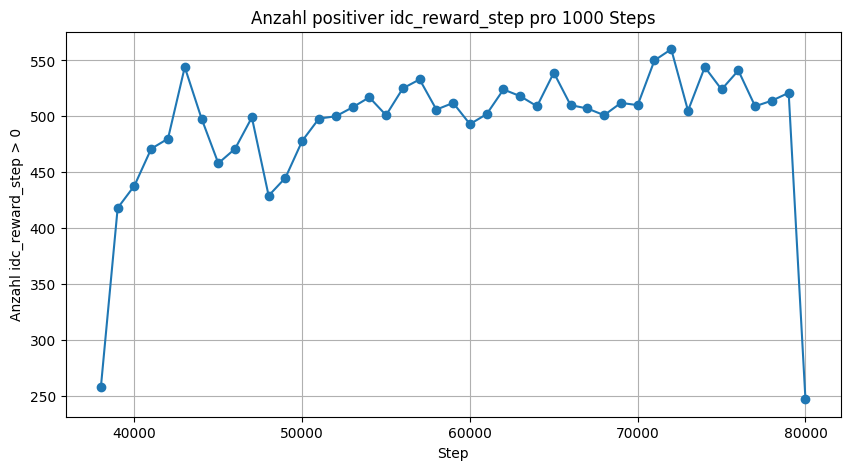

In [274]:
import matplotlib.pyplot as plt

step_size = 1000
test = test.loc[test.index >= 38_000]
test['step_bin'] = (test.index // step_size) * step_size

counts = (
    test['idc_reward_step']
    .gt(0)
    .groupby(test['step_bin'])
    .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(counts.index, counts.values, marker='o')
plt.xlabel('Step')
plt.ylabel('Anzahl idc_reward_step > 0')
plt.title('Anzahl positiver idc_reward_step pro 1000 Steps')
plt.grid(True)
plt.show()


In [275]:
singe_ri_results = pd.read_csv("../output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv", parse_dates=["day"])
singe_ri_results["day"] = pd.to_datetime(singe_ri_results["day"].astype(str).str.slice(0, 10), errors="coerce")
singe_ri_results["day"] = singe_ri_results["day"].dt.normalize()
singe_ri_results.set_index("day", inplace=True)
singe_ri_results

,profit,cycles
day,,
2019-01-01,68.233139,1.000000
2019-01-02,159.440419,2.000000
2019-01-03,56.598649,3.000000
2019-01-04,64.915423,4.000000
2019-01-05,102.020127,5.000000
...,...,...
2023-09-26,342.531022,1729.536319
2023-09-27,307.205984,1730.536319
2023-09-28,309.449274,1731.536319


In [276]:
summary.set_index("day", inplace=True)
summary = summary.join(singe_ri_results, lsuffix="_oracle", rsuffix="_single_ri")
summary

,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better,profit,cycles
day,,,,,,,,
2019-01-01,68.233139,90.535395,32.685373,6.0,21.270873,21.686798,68.233139,1.0
2019-01-02,159.440419,197.215422,23.692238,9.0,13.553811,17.031041,159.440419,2.0
2019-01-03,56.598649,69.355606,22.539332,5.0,12.155425,11.520344,56.598649,3.0
2019-01-04,64.915423,68.483540,5.496562,4.0,2.998181,3.103887,64.915423,4.0
2019-01-05,102.020127,112.988274,10.750964,2.0,6.751888,6.751888,102.020127,5.0
...,...,...,...,...,...,...,...,...
2020-12-26,108.226402,130.314885,20.409514,4.0,10.214697,9.845871,108.226402,726.0
2020-12-27,150.479823,211.893817,40.812112,16.0,16.028111,13.974827,150.479823,727.0
2020-12-28,130.278365,144.897575,11.221518,9.0,7.256599,7.802016,130.278365,728.0


In [277]:
summary["diff"]= summary["RI_base"] - summary["profit"]

<Axes: title={'center': 'Oracle vs Single RI Profit Comparison'}, xlabel='day'>

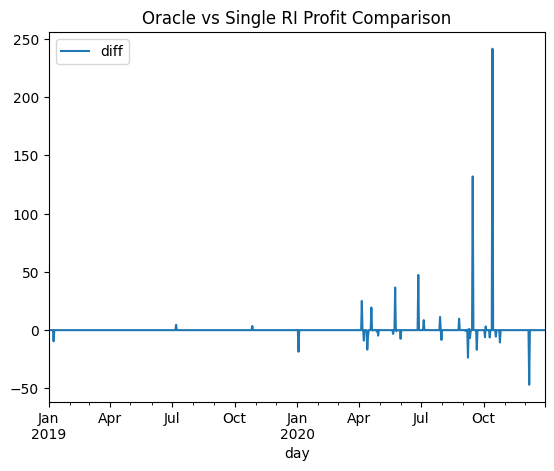

In [278]:
summary.plot(y=["diff"], title="Oracle vs Single RI Profit Comparison")

In [279]:
threshold = 0.01

n_days_diff = (summary["diff"].abs() > threshold).sum()

print(f"Anzahl Tage mit |diff| > {threshold}: {n_days_diff}")


Anzahl Tage mit |diff| > 0.01: 38


In [280]:
summary.loc[summary["diff"].abs() > 0.01].sort_values("diff", ascending=False).head(20)


,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better,profit,cycles,diff
day,,,,,,,,,
2020-10-14,319.946301,262.366395,-17.996741,0.0,0.000000,0.000000,78.238395,653.0,241.707906
2020-09-15,905.855102,1032.693221,14.002032,3.0,9.141508,9.419380,773.818973,624.0,132.036129
2020-06-27,89.663991,104.152204,16.158341,13.0,4.896581,2.575167,42.258873,544.0,47.405117
2020-05-24,269.796591,292.456886,8.399030,3.0,5.152225,3.852607,233.197071,510.0,36.599520
2020-04-05,254.178295,282.495112,11.140533,1.0,11.140533,11.140533,229.114149,461.0,25.064146
2020-04-19,200.057040,240.142524,20.037027,11.0,10.014562,11.440775,180.614211,475.0,19.442829
2020-07-29,130.154578,131.803353,1.266782,1.0,1.266782,1.266782,118.816327,576.0,11.338250
2020-08-26,210.908100,238.366450,13.019107,5.0,7.613387,7.986806,201.176595,604.0,9.731505
2020-07-05,146.181824,212.363310,45.273403,15.0,30.025665,31.910128,137.566705,552.0,8.615119
